# Fitting a random diffusion field on the correlations plot

Notebook servant a estimer le champ culturel

## Load data

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import os

In [2]:
def generate_filenames_and_file_labels(directory):
    # List all files in the directory
    files_in_directory = os.listdir(directory)
    filenames = [file for file in files_in_directory if file.endswith(".pkl")]

    # Initialize an empty dictionary to store the file labels
    file_labels = {}

    # Iterate through the files in the directory
    for file in files_in_directory:
        # Check if the file ends with '.pkl'
        if file.endswith(".pkl"):
            # Extract the year from the filename
            year = None
            if "pres" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "pres_" + year

            if "ref" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "ref_" + year

            if "leg" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "leg_" + year

            # Check if it's a T2 file
            if "T2" in file:
                file_labels[file] = f"T2_{year}"
            elif year:
                file_labels[file] = year

    return filenames, file_labels

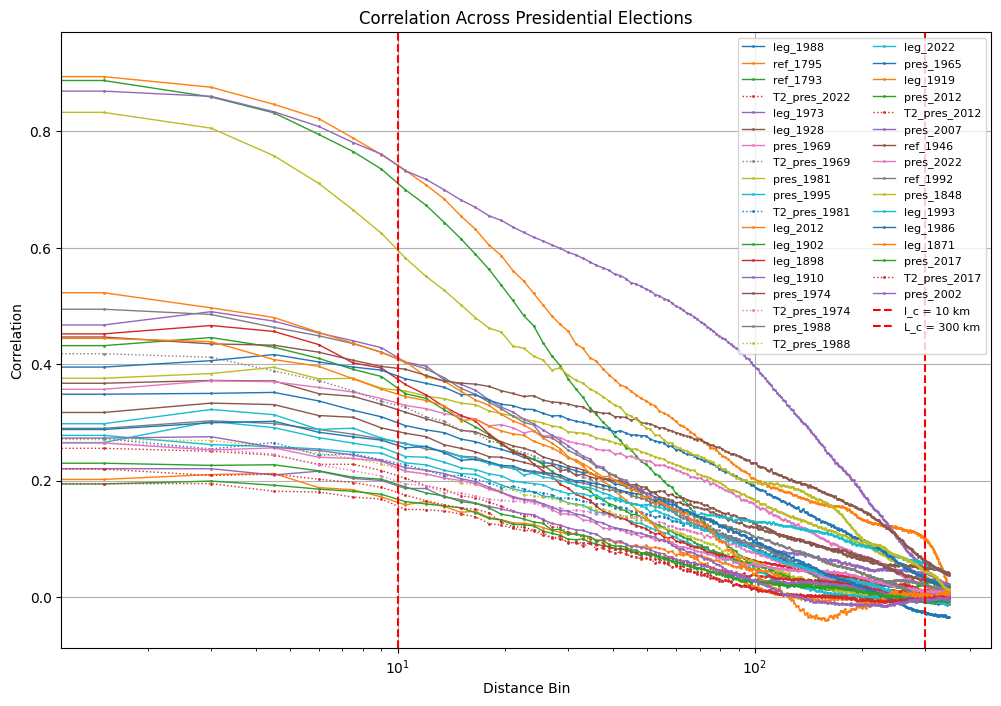

In [5]:
# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

filenames, file_labels = generate_filenames_and_file_labels(d)

# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Plot the data on the same graph
plt.figure(figsize=(12, 8))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
    else:
        linestyle = "-"  # Solid line for regular elections

    plt.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        marker="o",
        linestyle=linestyle,
        linewidth=1,
        markersize=1,
    )
plt.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
plt.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
plt.title("Correlation Across Presidential Elections")
plt.xlabel("Distance Bin")
plt.xscale("log")
plt.ylabel("Correlation")
plt.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()

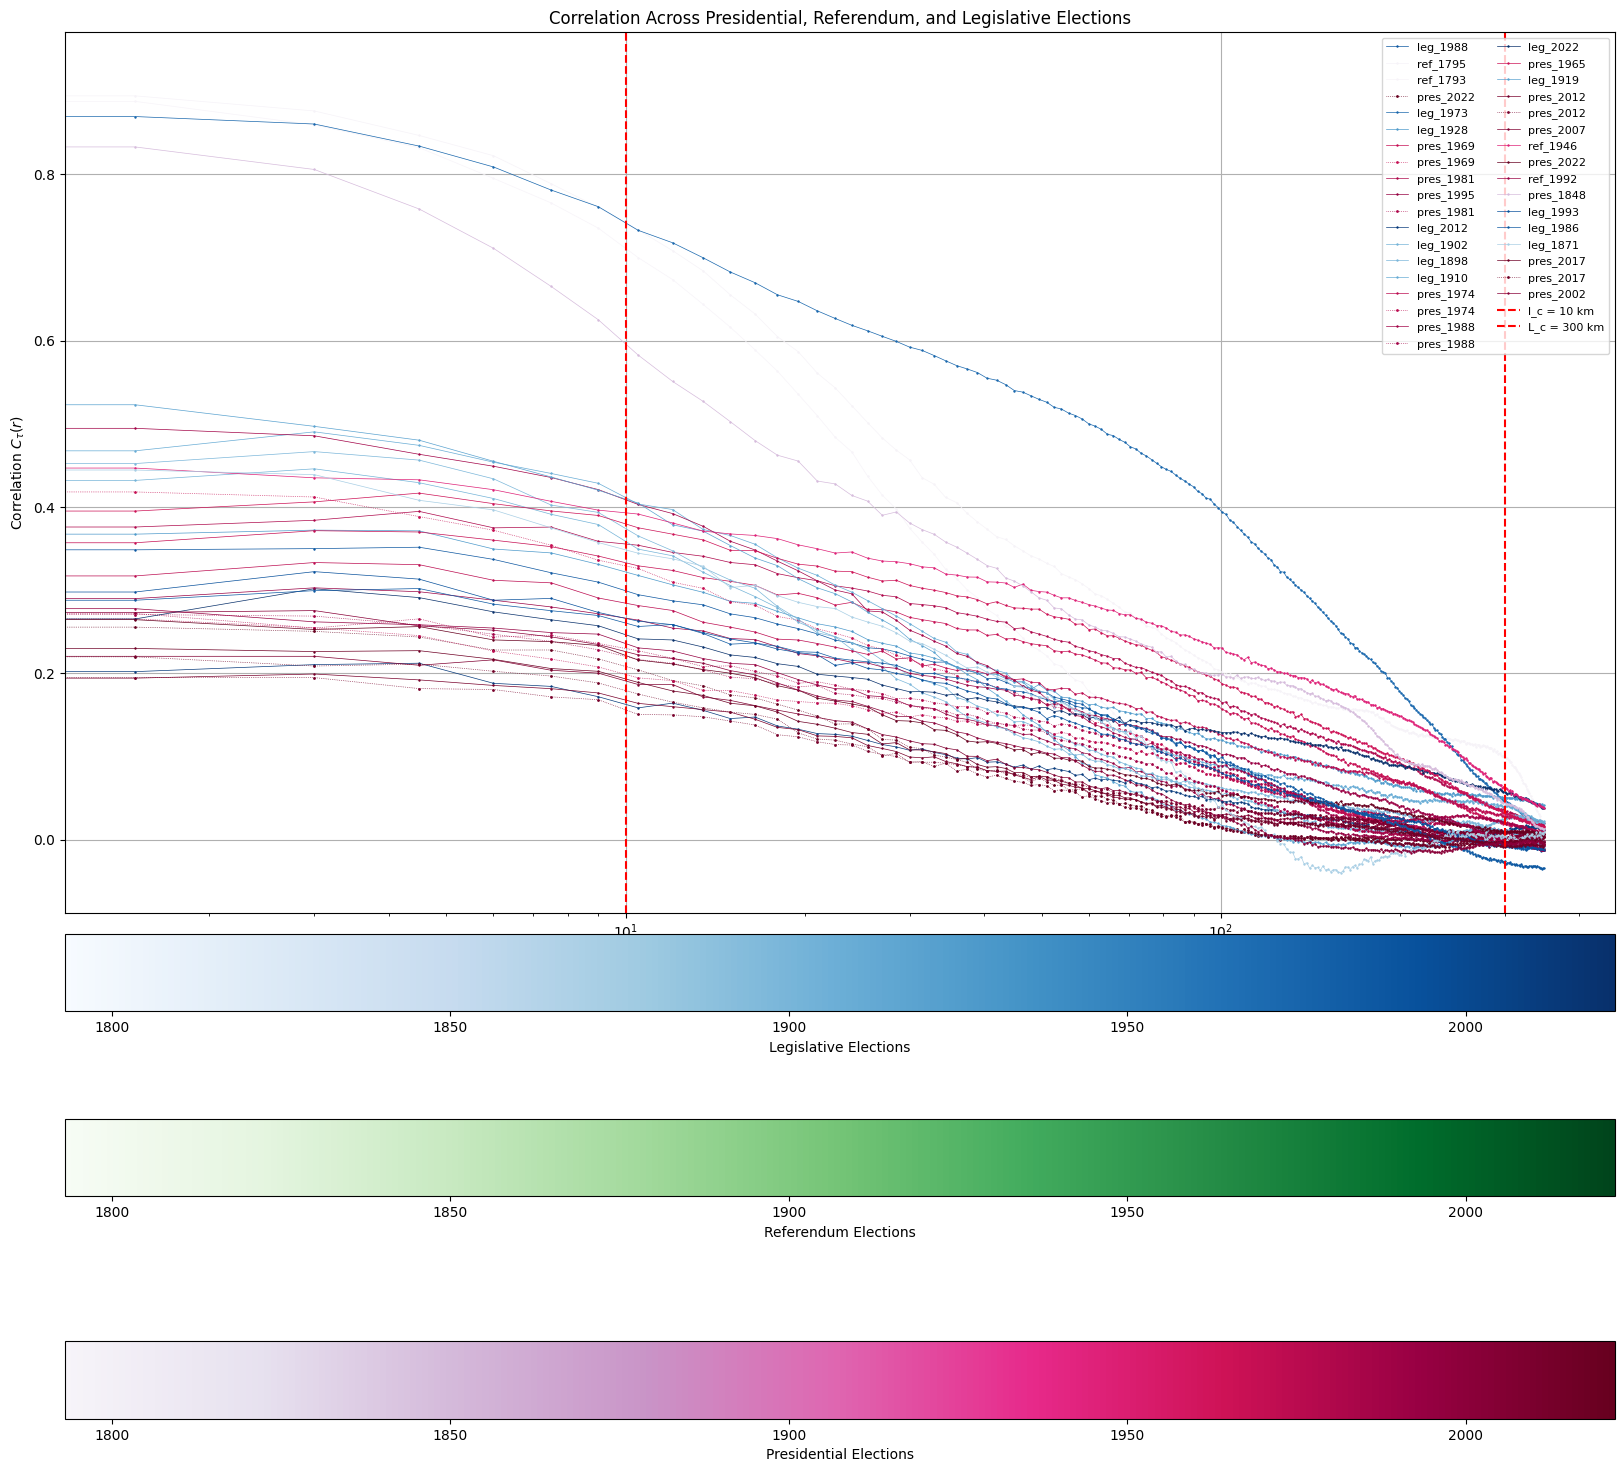

In [6]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year (removing prefix before '_')
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Define separate colormaps for each election type
colormap_pres = cm.PuRd  # Presidential elections
colormap_ref = cm.Greens  # Referendum elections
colormap_leg = cm.Blues  # Legislative elections


# Create a function to assign colormap based on election type
def get_colormap(election_type):
    if election_type == "pres":
        return colormap_pres
    elif election_type == "ref":
        return colormap_ref
    elif election_type == "leg":
        return colormap_leg
    else:
        return cm.viridis  # Default to viridis


# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 20))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    election_type = "pres"  # Default election type
    if "referendum" in label.lower():  # Check if the label refers to a referendum
        election_type = "ref"
    elif "leg" in label.lower():  # Check if the label refers to a legislative election
        election_type = "leg"

    colormap = get_colormap(election_type)  # Get the correct colormap
    years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
    normalize = plt.Normalize(min(years), max(years))
    colors = {year: colormap(normalize(year)) for year in years}

    # Check if the label is for T2 elections (runoff elections)
    if label.startswith("T2"):
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"

    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=0.5,
        markersize=1,
    )

# Add vertical lines at 10 km and 300 km
ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")

# Add labels and title
ax.set_title("Correlation Across Presidential, Referendum, and Legislative Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Create separate colorbars for each election type
# Plot for presidential elections
sm_pres = cm.ScalarMappable(cmap=colormap_pres, norm=normalize)
sm_pres.set_array([])
cbar_pres = plt.colorbar(sm_pres, ax=ax, orientation="horizontal", pad=0.02)
cbar_pres.set_label("Presidential Elections")

# Plot for referendum elections
sm_ref = cm.ScalarMappable(cmap=colormap_ref, norm=normalize)
sm_ref.set_array([])
cbar_ref = plt.colorbar(sm_ref, ax=ax, orientation="horizontal", pad=0.02)
cbar_ref.set_label("Referendum Elections")

# Plot for legislative elections
sm_leg = cm.ScalarMappable(cmap=colormap_leg, norm=normalize)
sm_leg.set_array([])
cbar_leg = plt.colorbar(sm_leg, ax=ax, orientation="horizontal", pad=0.02)
cbar_leg.set_label("Legislative Elections")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

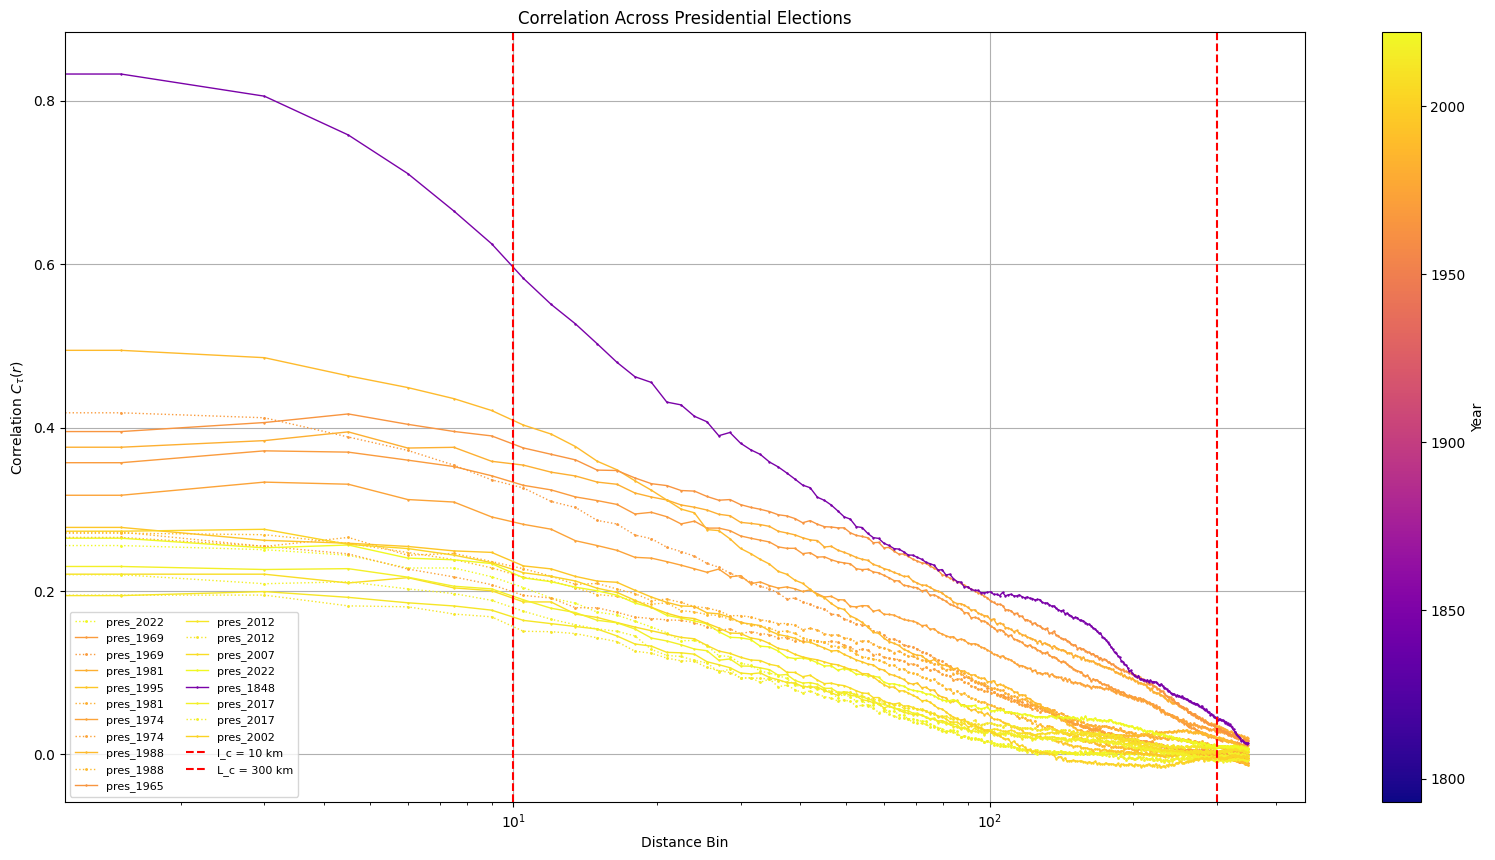

In [7]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "pres" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

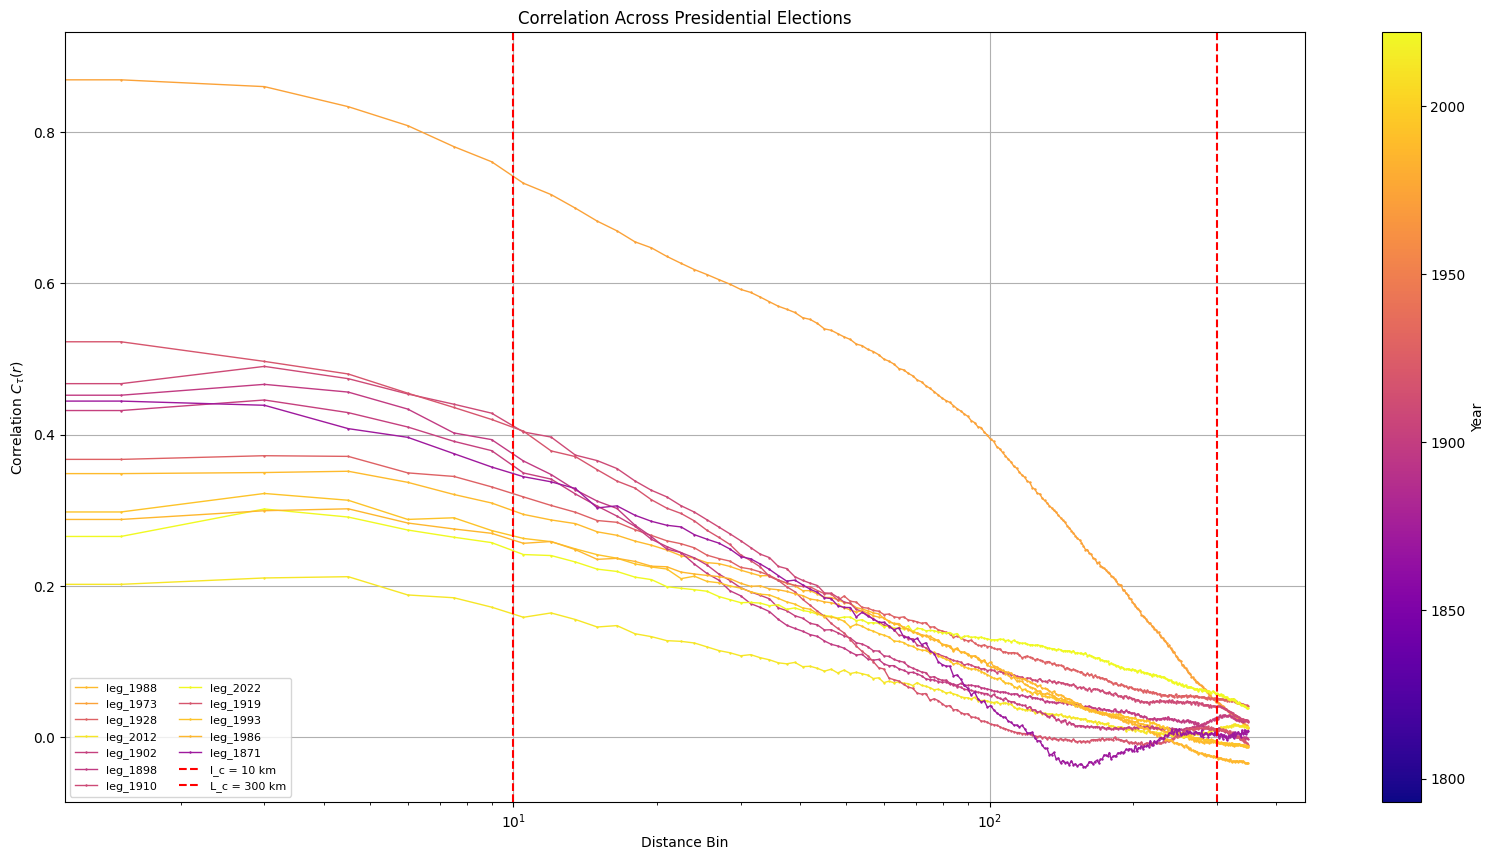

In [8]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "leg" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

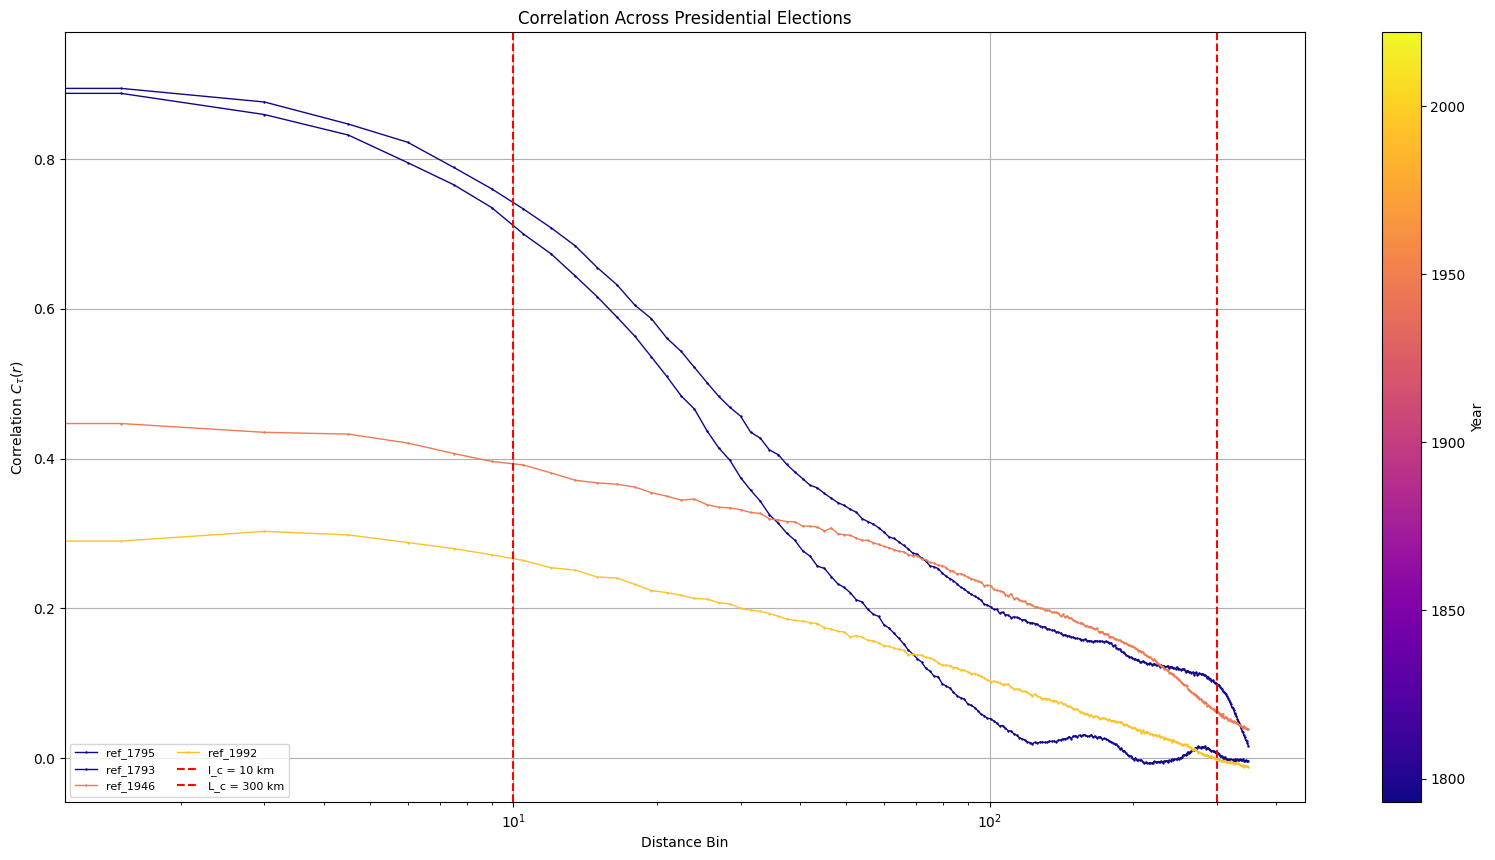

In [9]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "ref" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

Mean correlations plot

/var/folders/0w/963d6t99447bnvjg7_4qz3dc0000gn/T/ipykernel_79075/1795115120.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  DF = pd.concat([DF, temp_df], ignore_index=True)


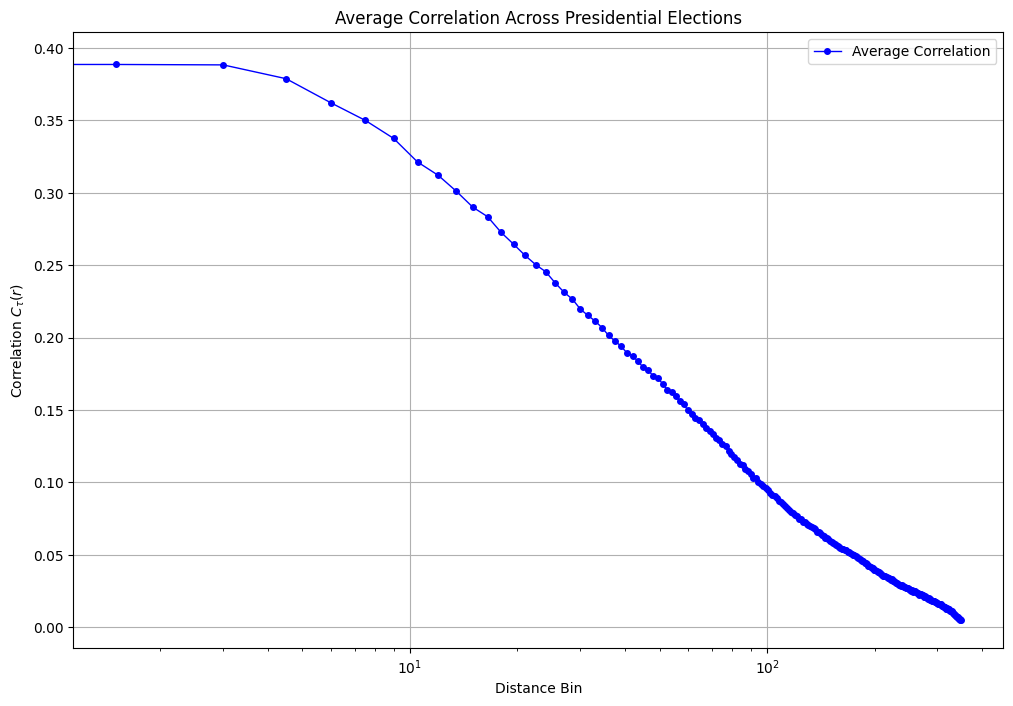

In [10]:
# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

# Initialize a dictionary to store DataFrames
dataframes = {}


# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(os.path.join(d, filename))
    label = file_labels[filename]
    dataframes[label] = pd.DataFrame(correlation_data)

# Combine data into a single DataFrame for aggregation
DF = pd.DataFrame(columns=["distance_bin", "correlation"])

# Loop through each DataFrame and append data to DF
for label, df in dataframes.items():
    temp_df = df[["distance_bin", "correlation"]].copy()
    DF = pd.concat([DF, temp_df], ignore_index=True)

# Group by distance_bin and calculate the mean correlation
avg_correlation = DF.groupby("distance_bin")["correlation"].mean().reset_index()

# Plot the data
fig, ax = plt.subplots(figsize=(12, 8))

# Plot average correlation
ax.plot(
    avg_correlation["distance_bin"] * 1.5,  # Adjust distance bin scaling
    avg_correlation["correlation"],
    label="Average Correlation",
    marker="o",
    linewidth=1,
    markersize=4,
    color="blue",
)

# Add labels and title
ax.set_title("Average Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")

# Add grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()

## Fitting

Soit $\phi(t, R)$ un champ bidemnsionnelle qui est régit par l'équation : 
$$
\dfrac{\partial \phi(t, R)}{\partial t} = d \Delta \phi(t, R) + \eta(t, R)
$$

Avec $C_{\phi}(r) = -\lambda^2  \log \left( \dfrac{r}{L} \right)$ for $l_c \leq r \leq L$

In [ ]:
l_c = 4.5
L_c = 300

In [ ]:
def get_lambda_L(slope, intercept):
    lambd = np.sqrt(-slope)
    L = np.exp(intercept / lambd**2)
    return lambd, L

In [ ]:
def fit_election(df, L_c, l_c, confidence_level=0.95, plot=True, resid=True):
    """
    This function will fit for a given election

    """
    C = df["correlation"]
    r = df["distance_bin"] * 1.5

    # Cut before l_c
    indices_ = np.where(r > l_c)[0]
    indices_2 = np.where(r < L_c)[0]
    indices = np.intersect1d(indices_, indices_2)
    C_ = C[indices].values
    r_ = r[indices].values
    r_log = np.log(r_)

    # Linear regression C = A*ln(r) = -lambda**2 * ln(r/L)
    r_reshaped = r_log.reshape(-1, 1)

    model = LinearRegression()
    model.fit(r_reshaped, C_)

    slope = model.coef_[0]
    intercept = model.intercept_
    print(f"Fitted line: C = {slope:.3f} * ln(r) + {intercept:.3f}")

    R_2 = model.score(r_reshaped, C_)
    print("Quality of the regression : " + str(R_2))

    residuals = C_ - model.predict(r_reshaped)
    n = len(C_)
    p = 1

    mse = np.sum(residuals**2) / (n - p - 1)
    se_slope = np.sqrt(mse / np.sum((r_reshaped - np.mean(r_reshaped)) ** 2))
    se_intercept = np.sqrt(
        mse
        * (
            1 / n
            + np.mean(r_reshaped) ** 2 / np.sum((r_reshaped - np.mean(r_reshaped)) ** 2)
        )
    )  # Standard error of the intercept

    t_value = stats.t.ppf(1 - (1 - confidence_level) / 2, df=n - p - 1)

    slope_ci = (slope - t_value * se_slope, slope + t_value * se_slope)
    intercept_ci = (
        intercept - t_value * se_intercept,
        intercept + t_value * se_intercept,
    )

    lambd, L = get_lambda_L(slope, intercept)

    # Propagate uncertainty for lambd
    se_lambd = (1 / (2 * np.sqrt(-slope))) * se_slope
    lambd_ci = (lambd - t_value * se_lambd, lambd + t_value * se_lambd)

    # Propagate uncertainty for L
    se_L = (L / slope) * se_intercept + (L * intercept / slope**2) * se_slope
    L_ci = (L - t_value * se_L, L + t_value * se_L)

    lambd, L = get_lambda_L(slope, intercept)
    print(f"C = -({lambd**2:.3f}+/-{se_lambd:.3f}) * ln(r/({L:.3f}+/-{se_L:.3f}))")

    if plot:
        # Plot curve and fit
        plt.figure(figsize=(8, 6))
        plt.scatter(r_, C_, color="blue", label="Data", s=1)
        plt.plot(r_, model.predict(r_reshaped), color="red", label="Fitted Line")
        plt.xlabel("r (km)")
        plt.xscale("log")
        plt.ylabel("C (correlation)")
        plt.legend()
        plt.show()

    if resid:
        # Plot residuals
        plt.figure(figsize=(8, 6))
        plt.scatter(r_, residuals, color="green", s=4)
        plt.axhline(0, color="black", linestyle="--")
        plt.xlabel("r")
        plt.ylabel("Residuals")
        plt.title("Residuals of the Fit")
        plt.show()

    return lambd, L, R_2

leg_1988
Fitted line: C = -0.099 * ln(r) + 0.551
Quality of the regression : 0.9901180001468673
C = -(0.099+/-0.001) * ln(r/(254.747+/-1.268))


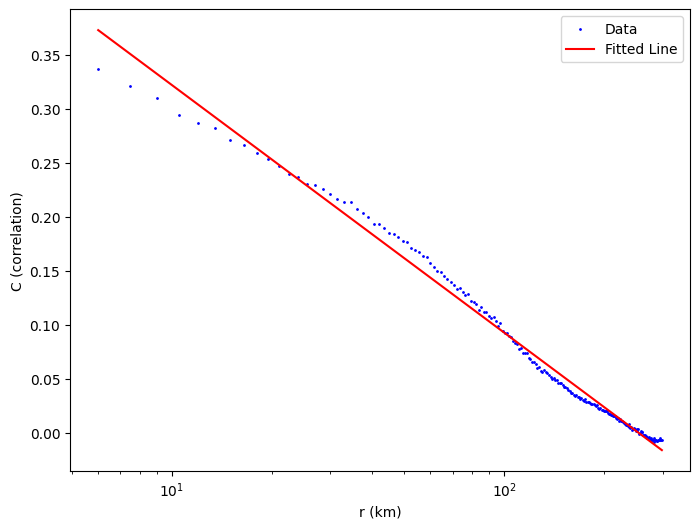

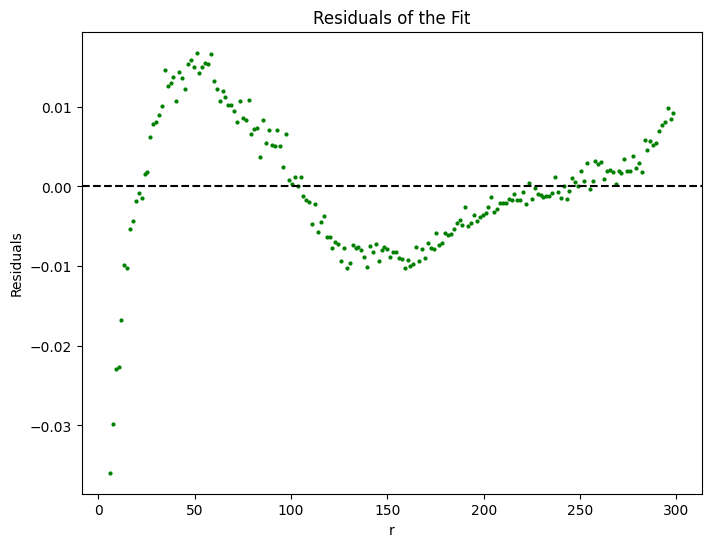

ref_1795
Fitted line: C = -0.171 * ln(r) + 1.037
Quality of the regression : 0.9458111918738427
C = -(0.171+/-0.004) * ln(r/(425.454+/-8.822))


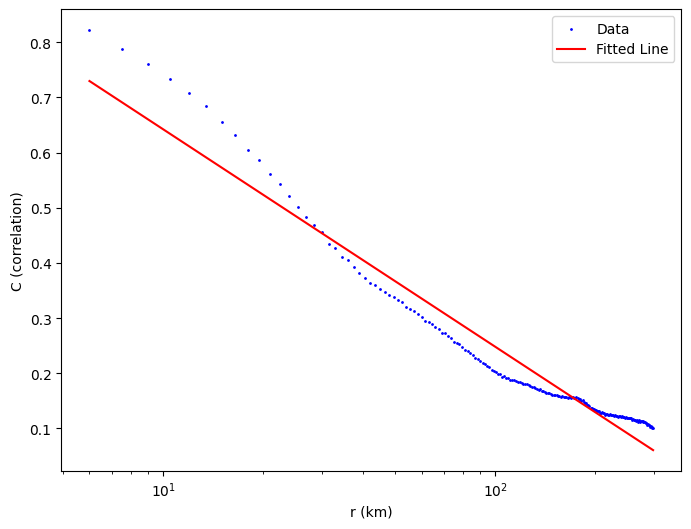

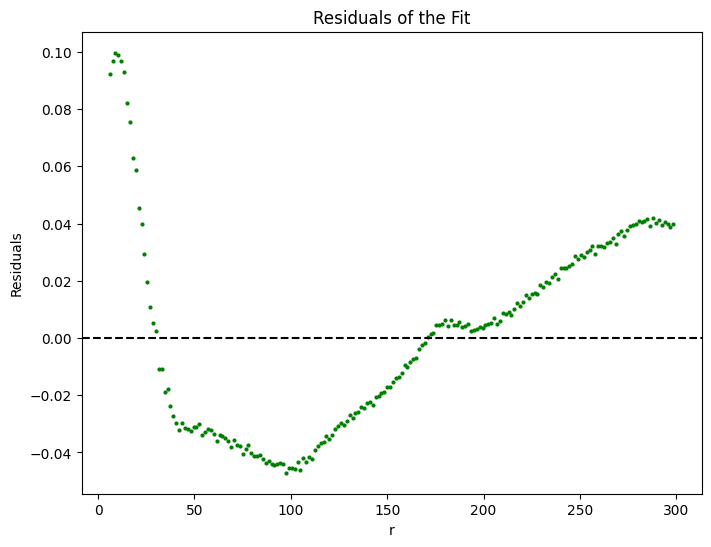

ref_1793
Fitted line: C = -0.190 * ln(r) + 1.005
Quality of the regression : 0.8825094815728851
C = -(0.190+/-0.006) * ln(r/(199.238+/-2.338))


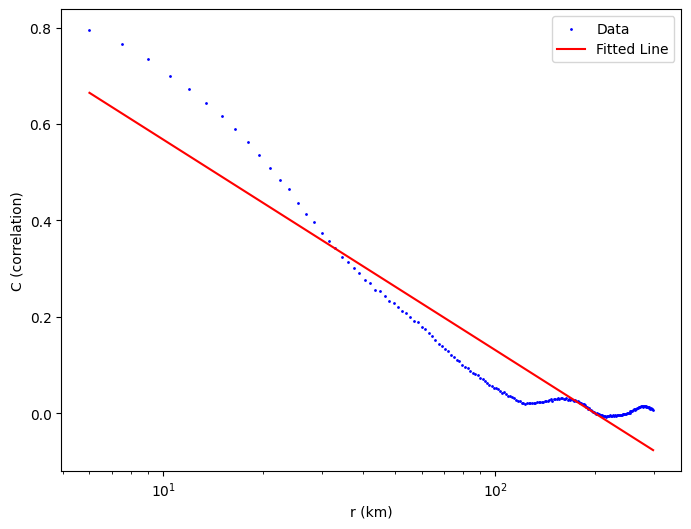

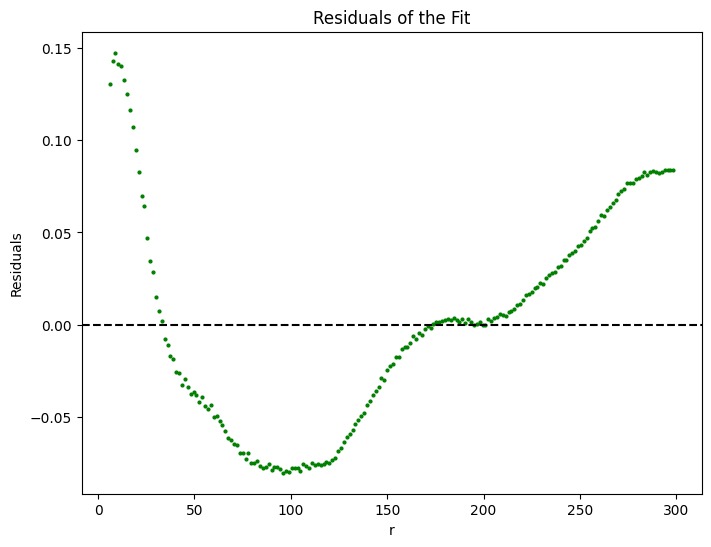

T2_pres_2022
Fitted line: C = -0.057 * ln(r) + 0.299
Quality of the regression : 0.8889565927884628
C = -(0.057+/-0.003) * ln(r/(193.680+/-2.062))


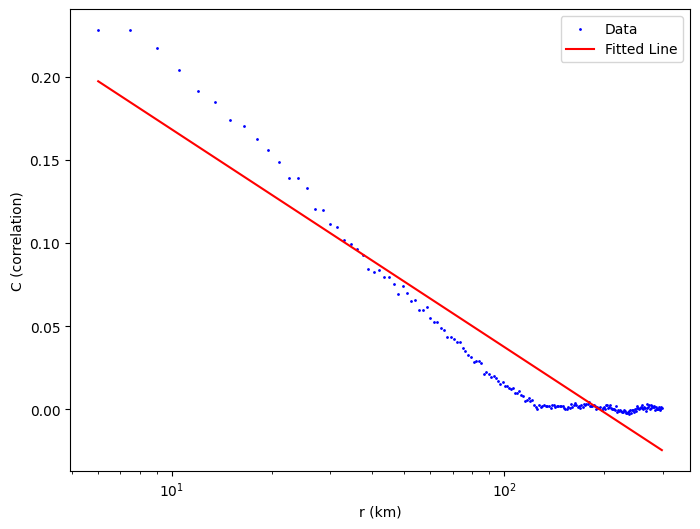

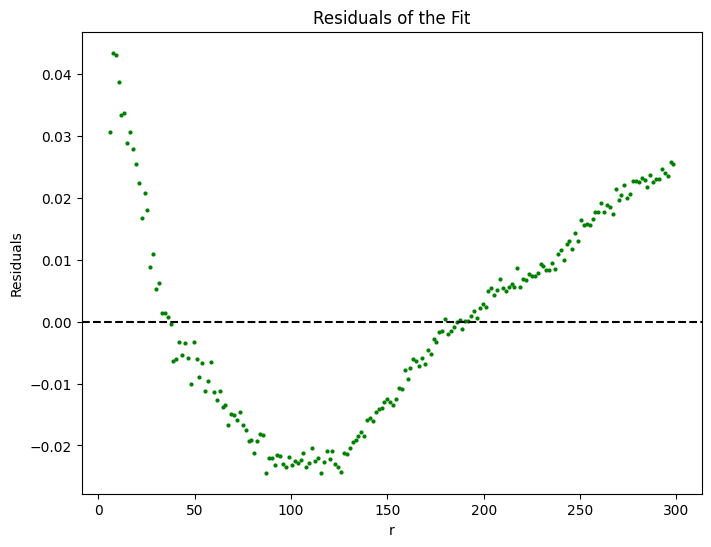

leg_1973
Fitted line: C = -0.221 * ln(r) + 1.359
Quality of the regression : 0.9516097840926191
C = -(0.221+/-0.004) * ln(r/(465.164+/-9.759))


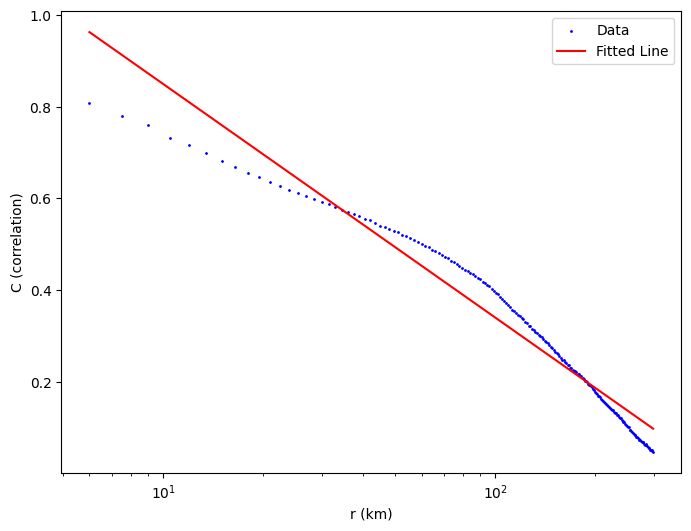

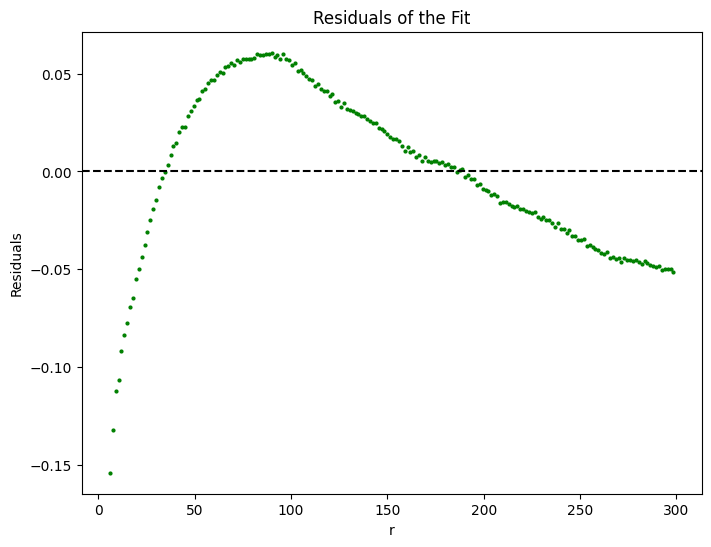

leg_1928
Fitted line: C = -0.081 * ln(r) + 0.500
Quality of the regression : 0.9926295867498192
C = -(0.081+/-0.001) * ln(r/(466.347+/-3.746))


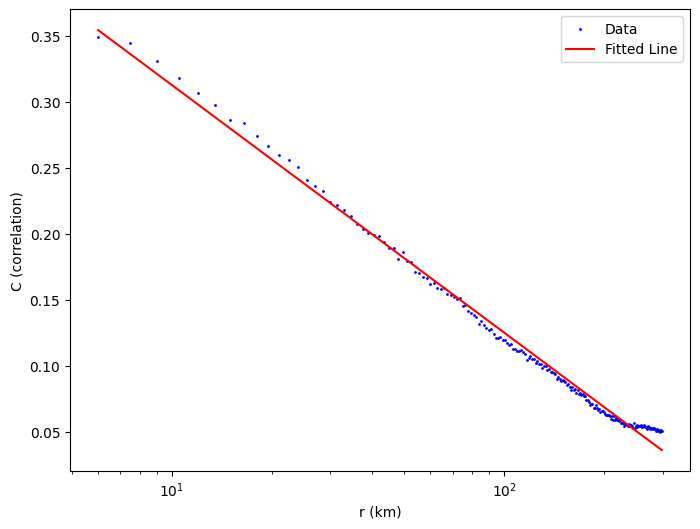

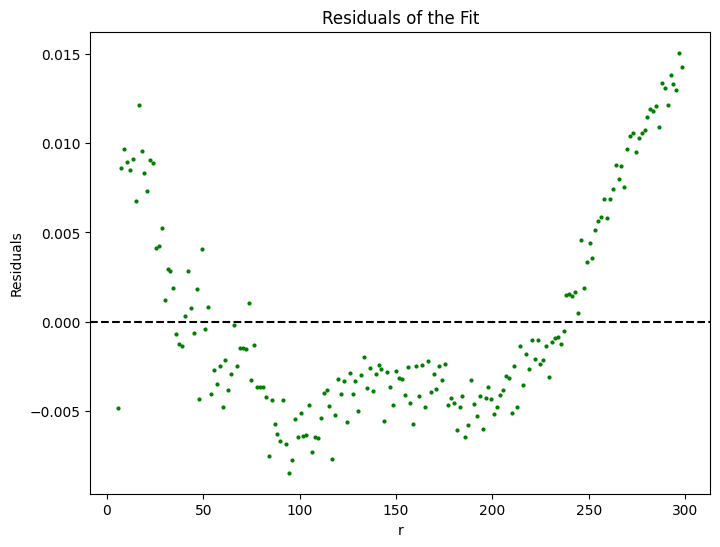

pres_1969
Fitted line: C = -0.102 * ln(r) + 0.612
Quality of the regression : 0.9715790584003317
C = -(0.102+/-0.002) * ln(r/(414.389+/-6.006))


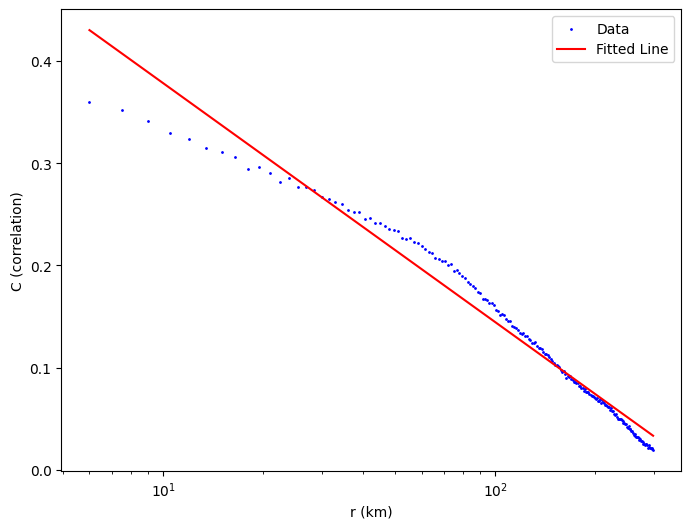

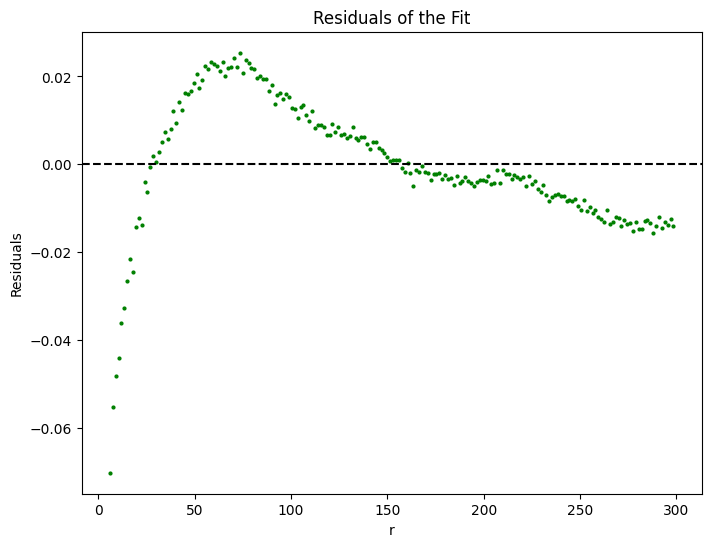

T2_pres_1969
Fitted line: C = -0.100 * ln(r) + 0.550
Quality of the regression : 0.9875006761706565
C = -(0.100+/-0.001) * ln(r/(249.244+/-1.353))


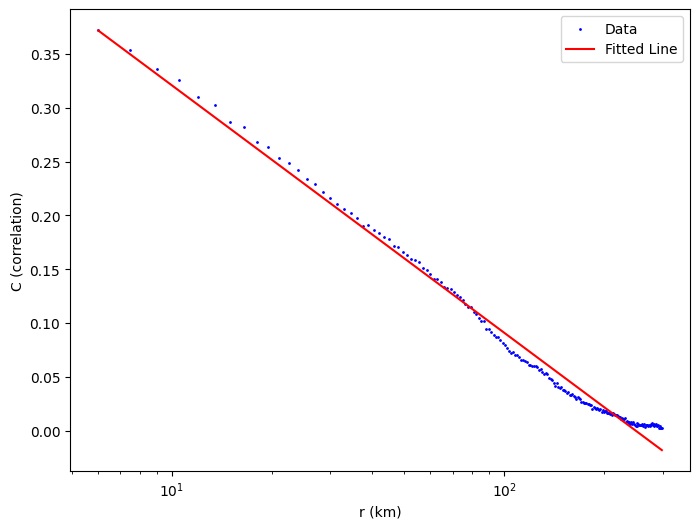

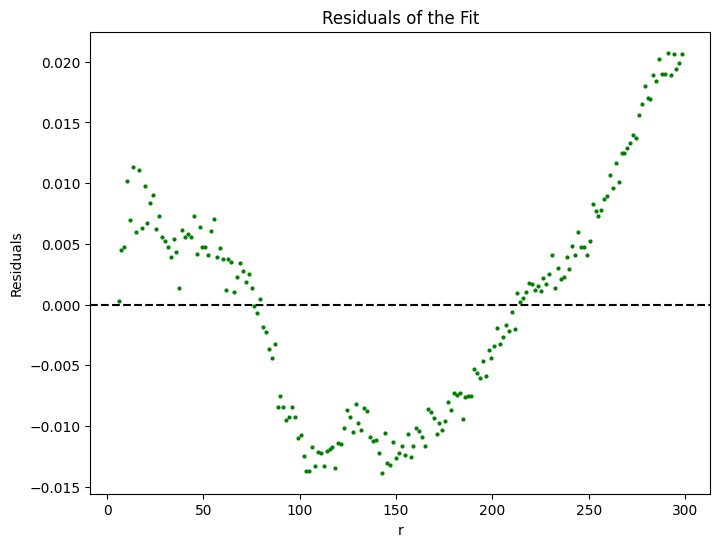

pres_1981
Fitted line: C = -0.101 * ln(r) + 0.626
Quality of the regression : 0.9812251174937464
C = -(0.101+/-0.002) * ln(r/(486.352+/-6.474))


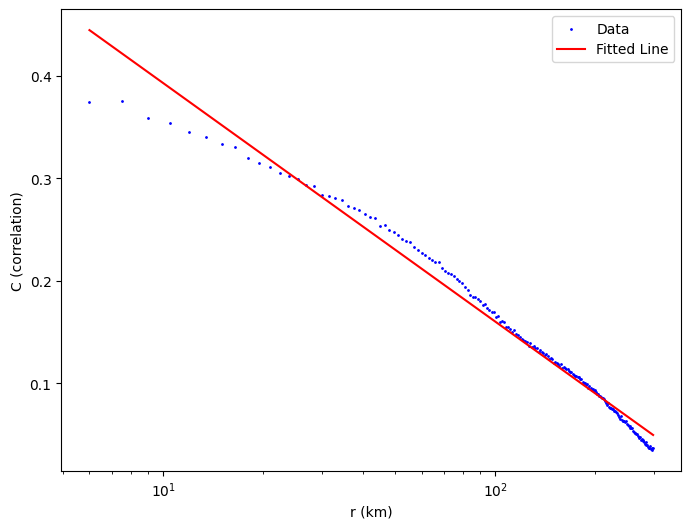

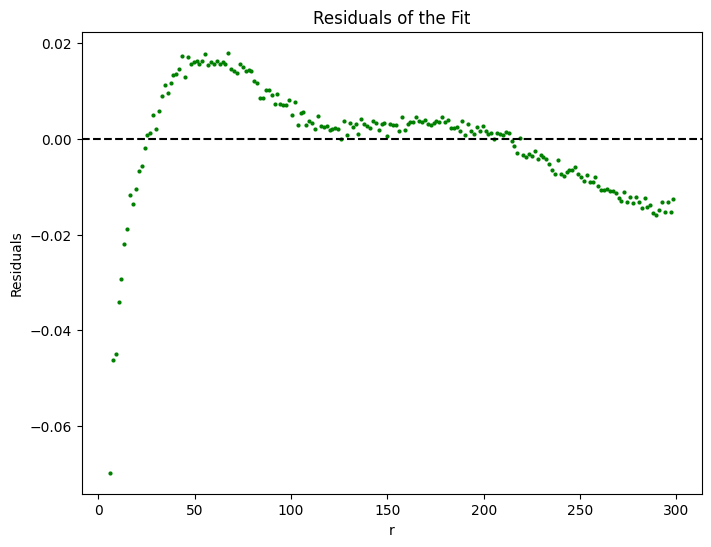

pres_1995
Fitted line: C = -0.076 * ln(r) + 0.408
Quality of the regression : 0.964345518483802
C = -(0.076+/-0.002) * ln(r/(214.571+/-1.546))


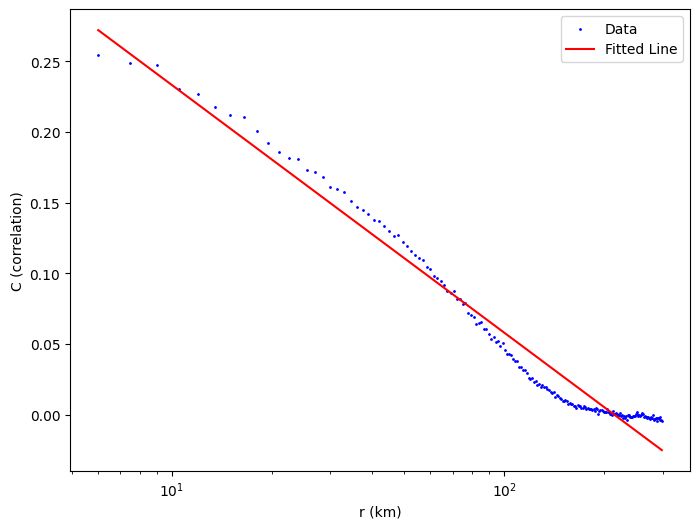

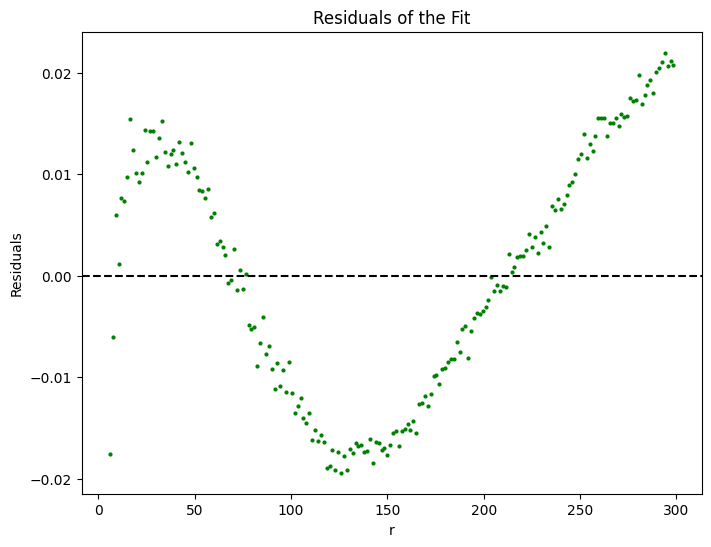

T2_pres_1981
Fitted line: C = -0.071 * ln(r) + 0.406
Quality of the regression : 0.9828846798011595
C = -(0.071+/-0.001) * ln(r/(313.903+/-2.684))


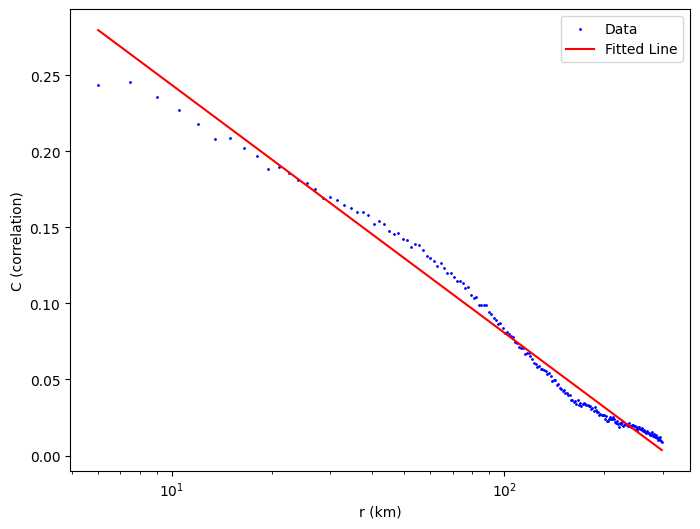

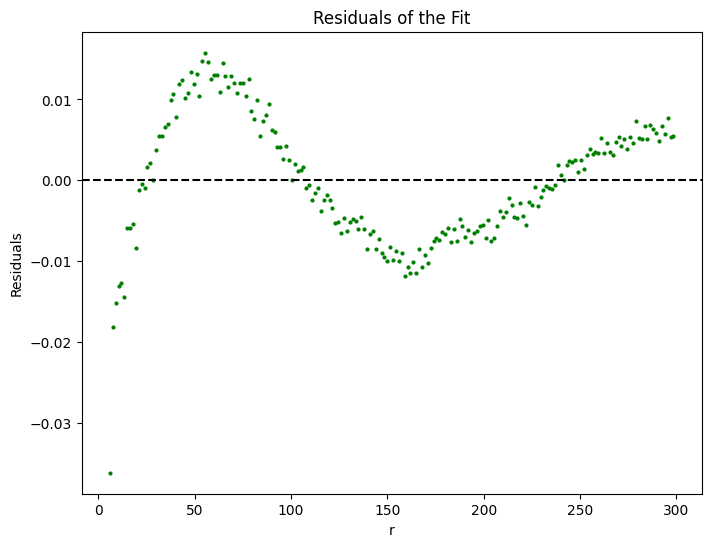

leg_2012
Fitted line: C = -0.050 * ln(r) + 0.281
Quality of the regression : 0.9889314835068841
C = -(0.050+/-0.001) * ln(r/(262.568+/-1.444))


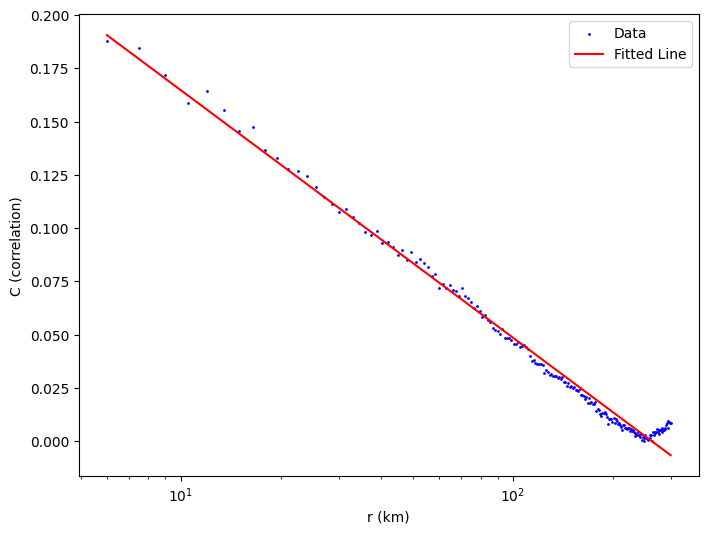

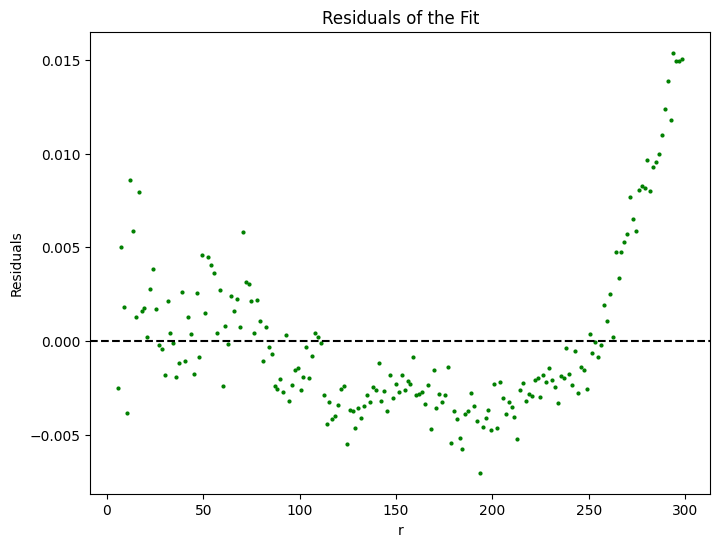

leg_1902
Fitted line: C = -0.096 * ln(r) + 0.519
Quality of the regression : 0.9149445090910204
C = -(0.096+/-0.003) * ln(r/(228.924+/-2.941))


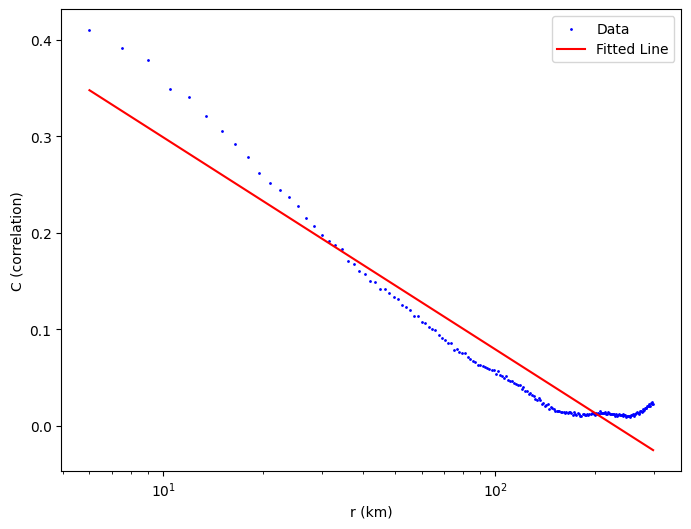

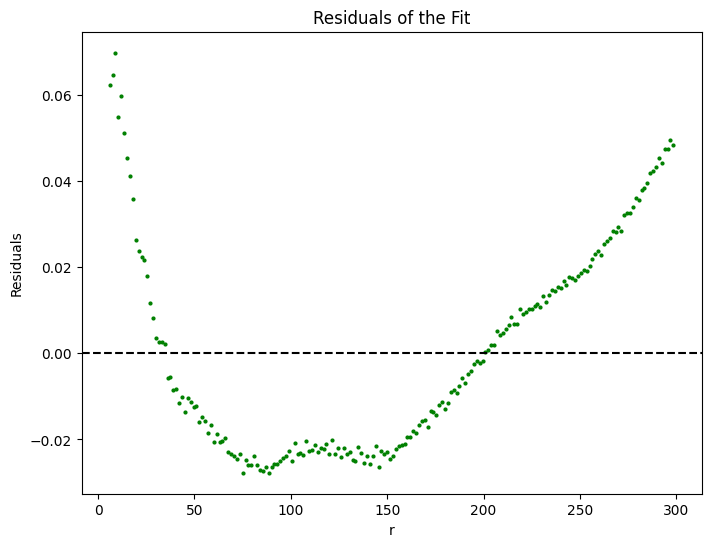

leg_1898
Fitted line: C = -0.090 * ln(r) + 0.498
Quality of the regression : 0.9017255492190226
C = -(0.090+/-0.004) * ln(r/(260.608+/-4.425))


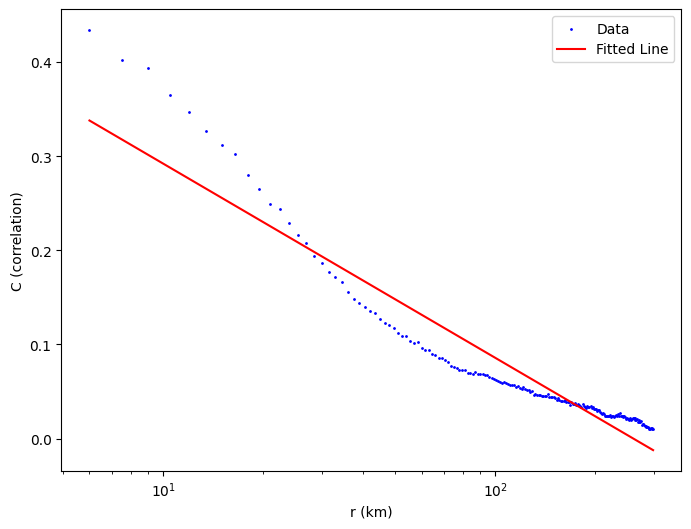

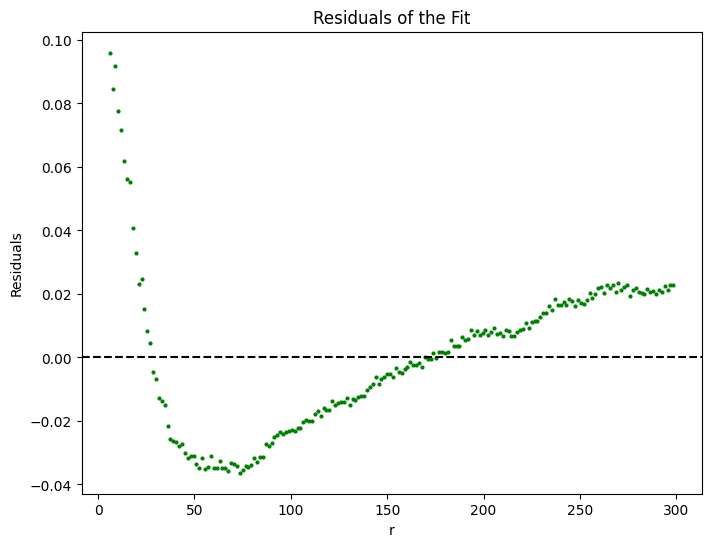

leg_1910
Fitted line: C = -0.103 * ln(r) + 0.595
Quality of the regression : 0.9298387535932923
C = -(0.103+/-0.003) * ln(r/(322.492+/-5.912))


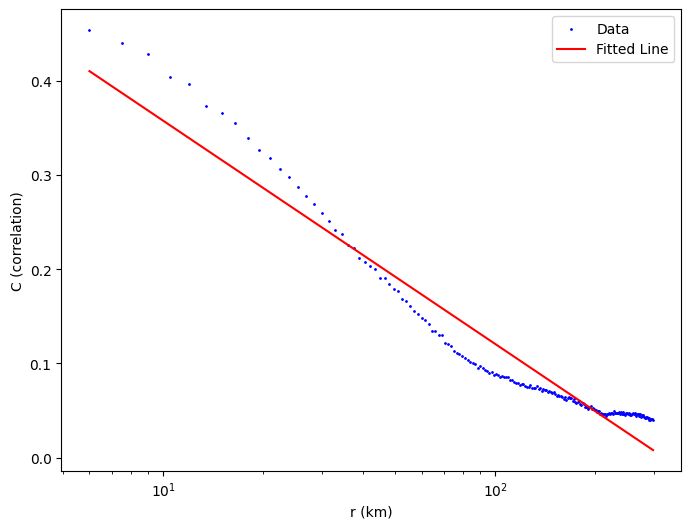

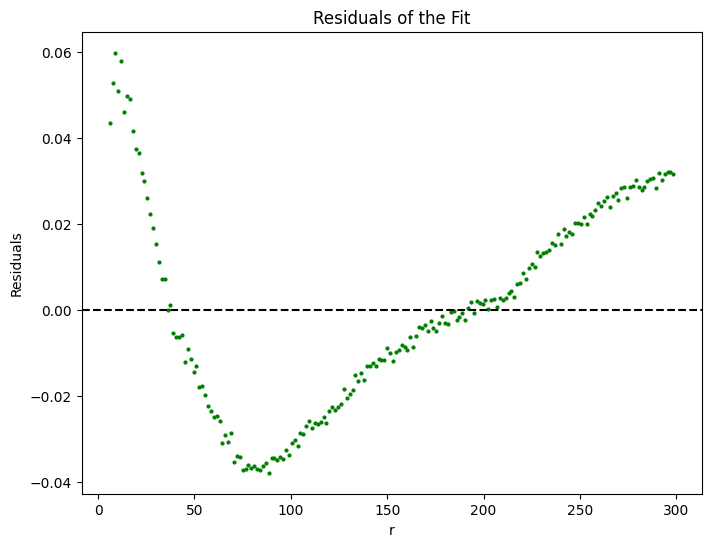

pres_1974
Fitted line: C = -0.079 * ln(r) + 0.484
Quality of the regression : 0.9887809325699861
C = -(0.079+/-0.001) * ln(r/(467.477+/-4.650))


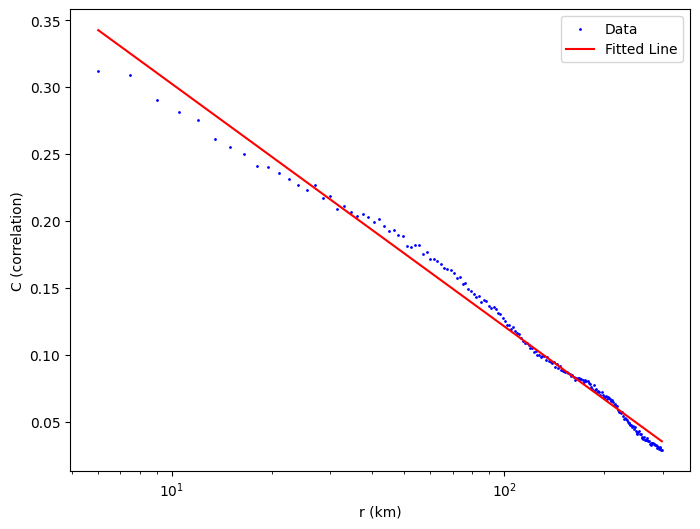

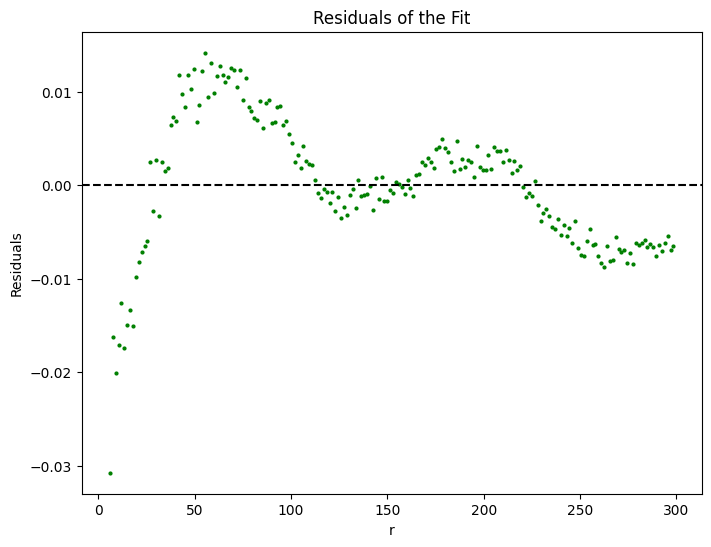

T2_pres_1974
Fitted line: C = -0.066 * ln(r) + 0.376
Quality of the regression : 0.9760538970417099
C = -(0.066+/-0.001) * ln(r/(286.903+/-2.622))


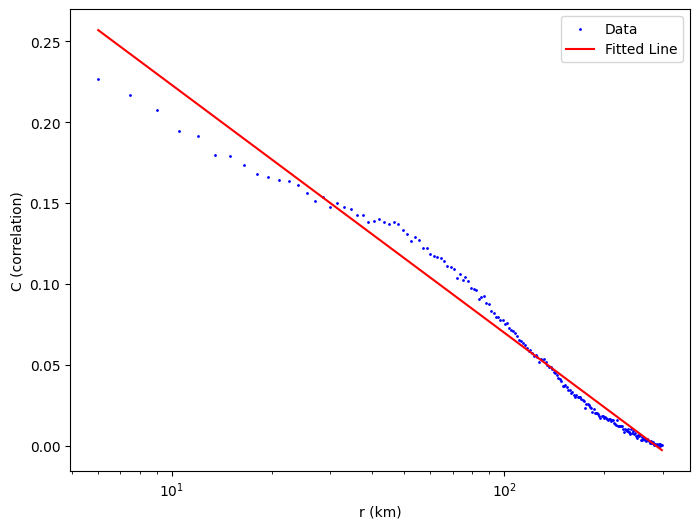

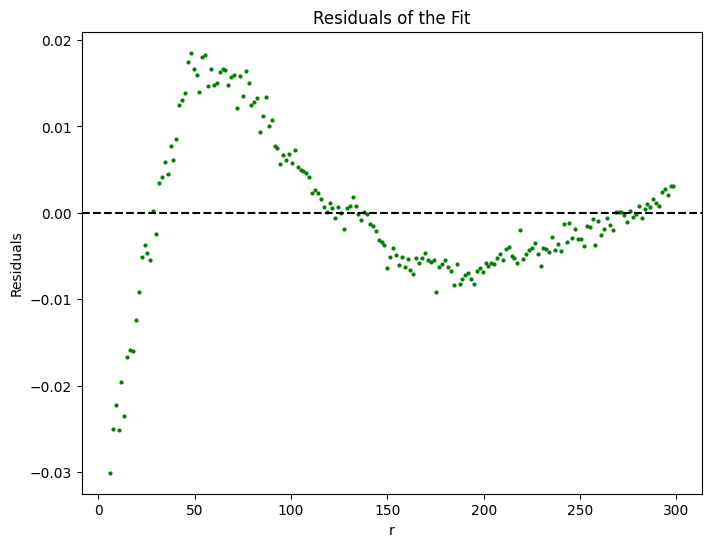

pres_1988
Fitted line: C = -0.112 * ln(r) + 0.622
Quality of the regression : 0.9439690601195609
C = -(0.112+/-0.003) * ln(r/(258.867+/-3.214))


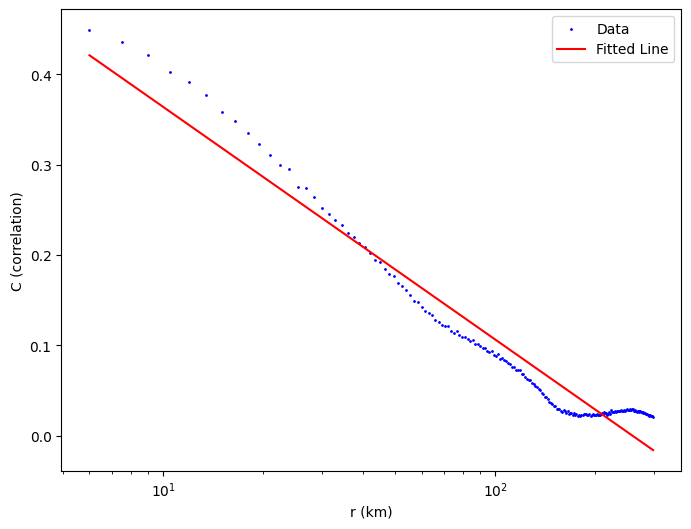

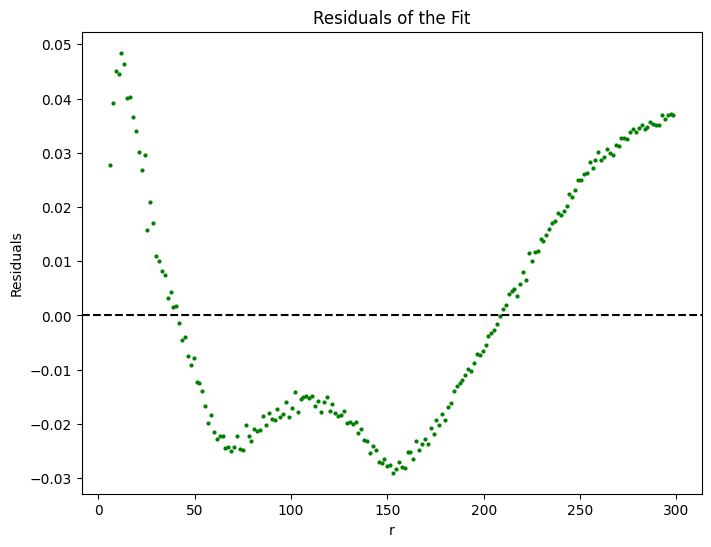

T2_pres_1988
Fitted line: C = -0.073 * ln(r) + 0.401
Quality of the regression : 0.9762774825044255
C = -(0.073+/-0.002) * ln(r/(240.606+/-1.714))


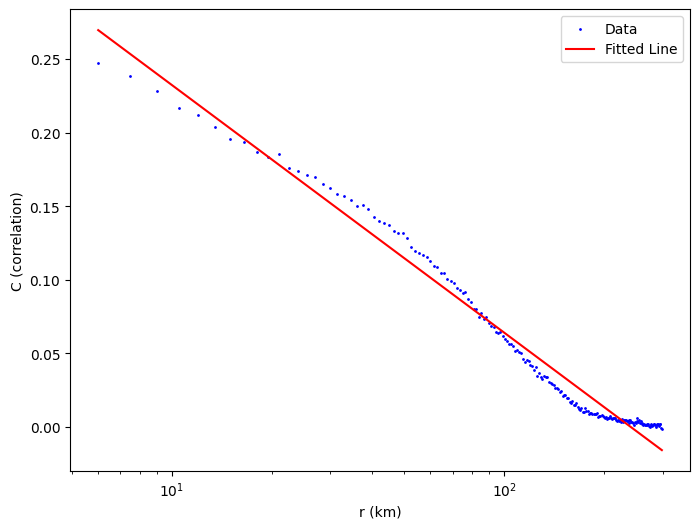

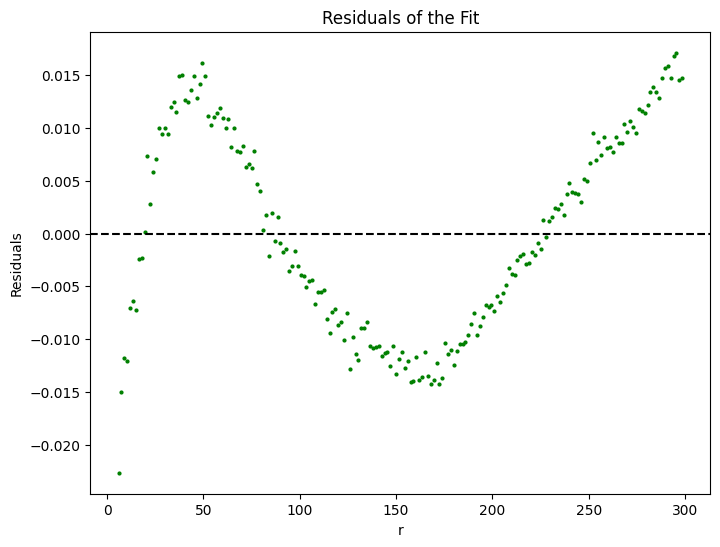

leg_2022
Fitted line: C = -0.053 * ln(r) + 0.369
Quality of the regression : 0.9818172077291565
C = -(0.053+/-0.001) * ln(r/(1055.799+/-21.823))


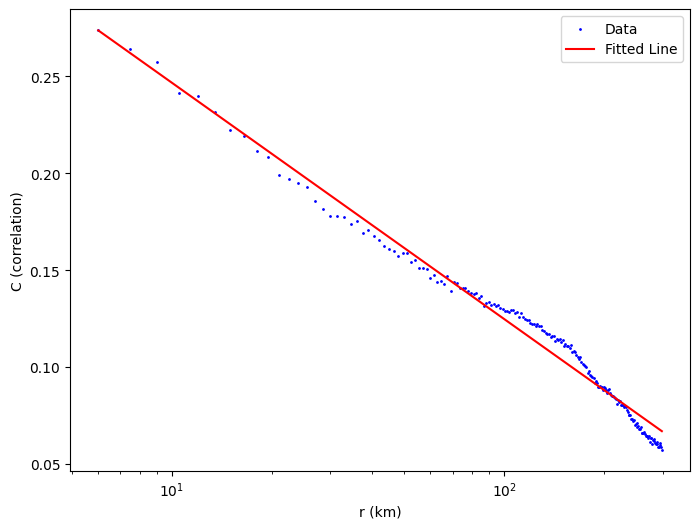

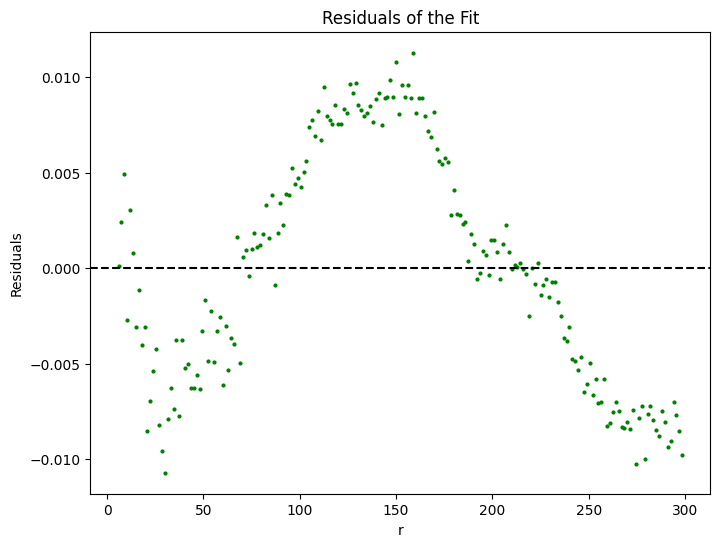

pres_1965
Fitted line: C = -0.110 * ln(r) + 0.680
Quality of the regression : 0.967465888283348
C = -(0.110+/-0.002) * ln(r/(489.185+/-8.670))


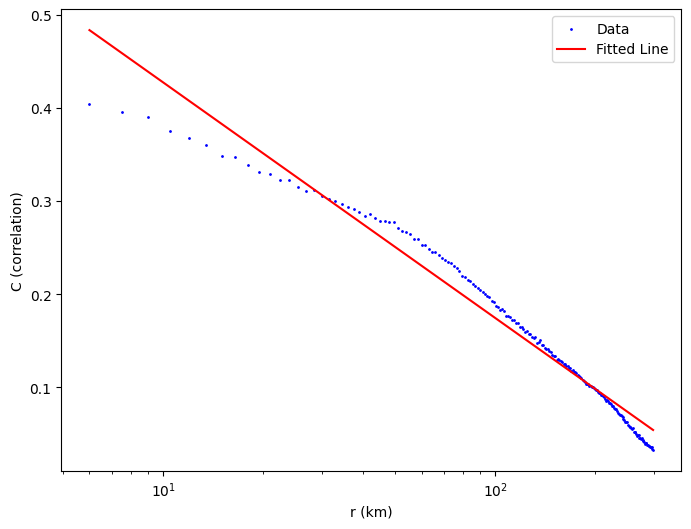

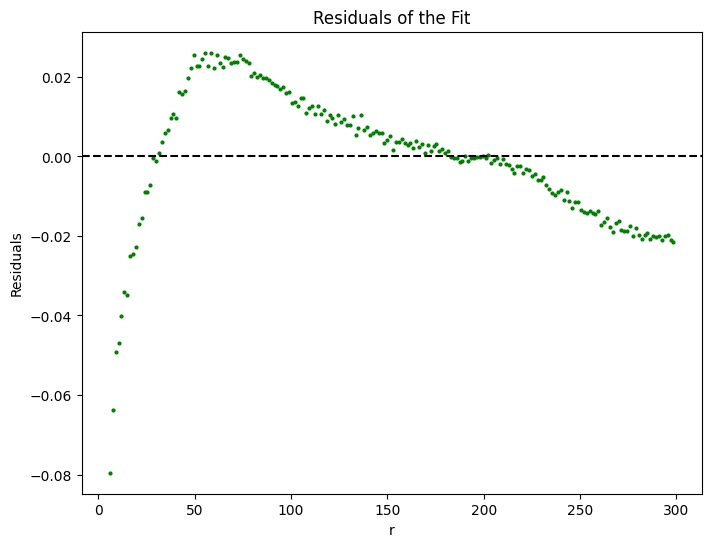

leg_1919
Fitted line: C = -0.113 * ln(r) + 0.589
Quality of the regression : 0.844146667903134
C = -(0.113+/-0.005) * ln(r/(187.243+/-2.229))


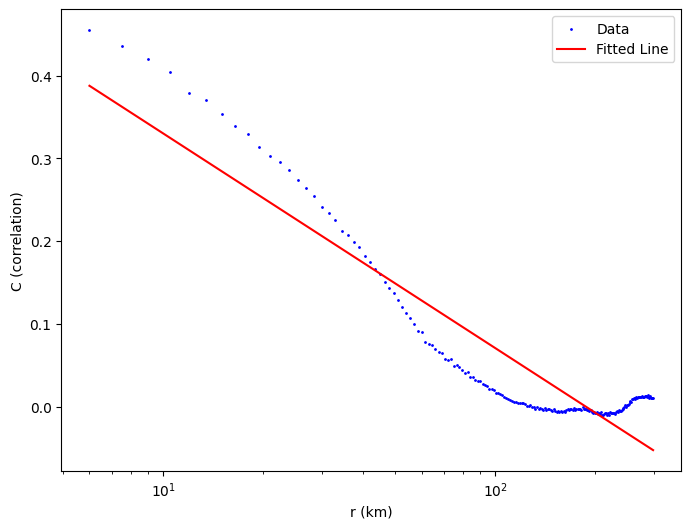

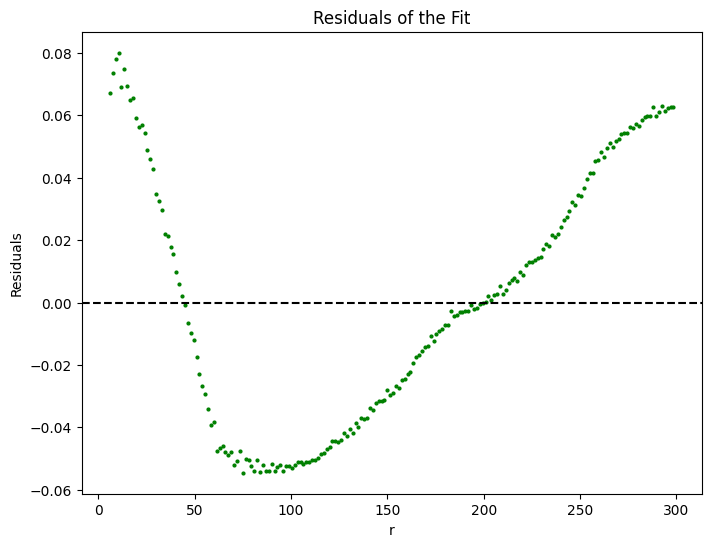

pres_2012
Fitted line: C = -0.047 * ln(r) + 0.259
Quality of the regression : 0.9513571856895526
C = -(0.047+/-0.002) * ln(r/(241.320+/-2.506))


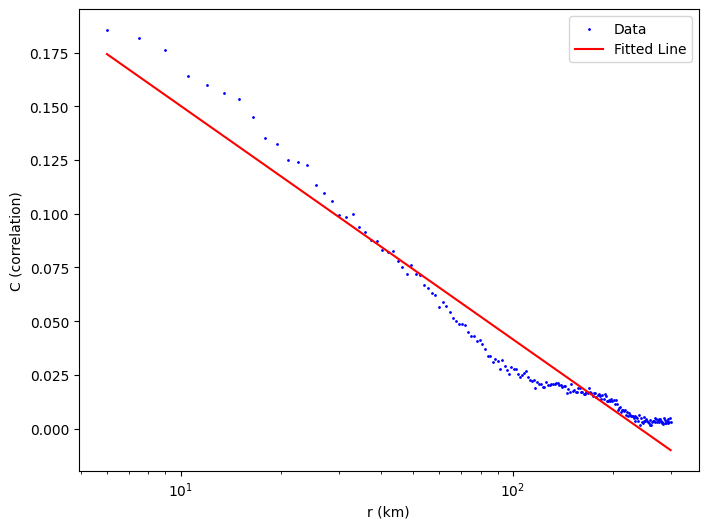

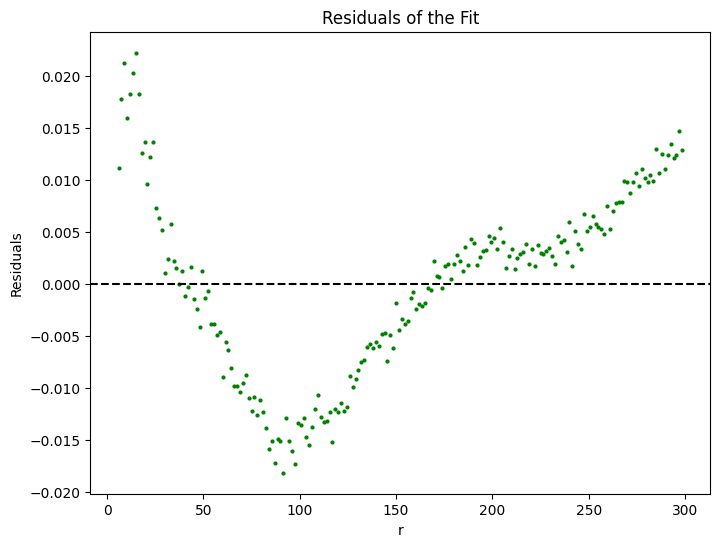

T2_pres_2012
Fitted line: C = -0.043 * ln(r) + 0.244
Quality of the regression : 0.9745217421780548
C = -(0.043+/-0.001) * ln(r/(292.729+/-2.830))


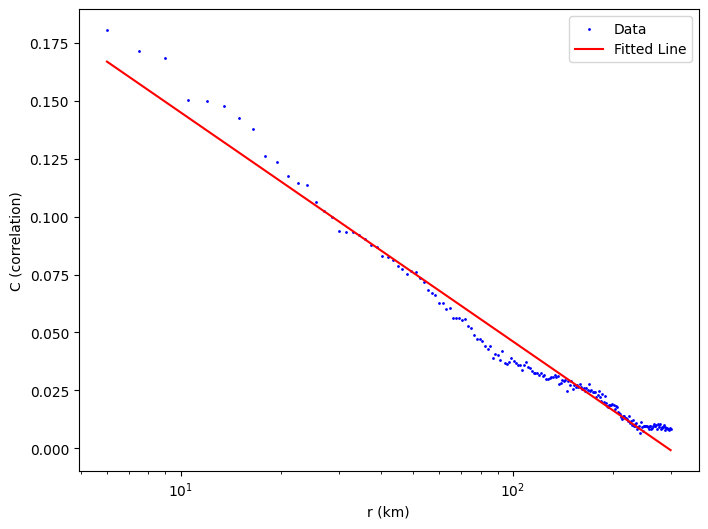

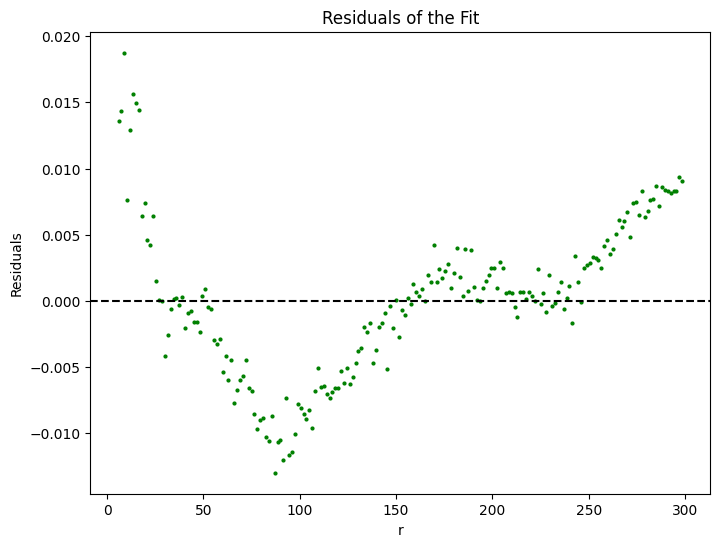

pres_2007
Fitted line: C = -0.054 * ln(r) + 0.296
Quality of the regression : 0.9552408031254642
C = -(0.054+/-0.002) * ln(r/(242.959+/-2.440))


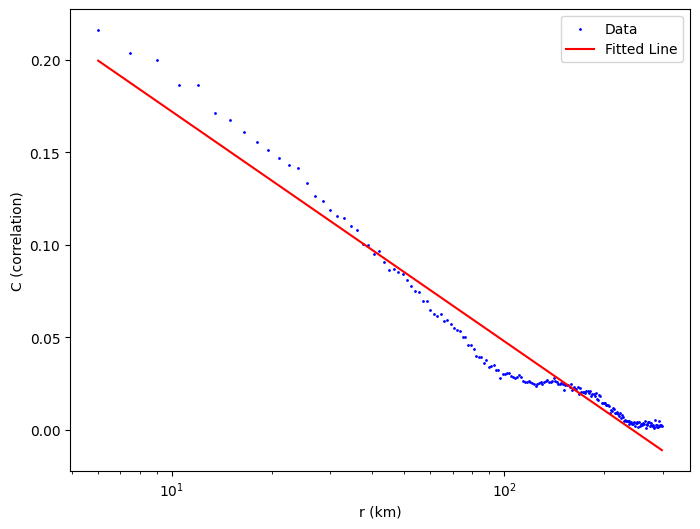

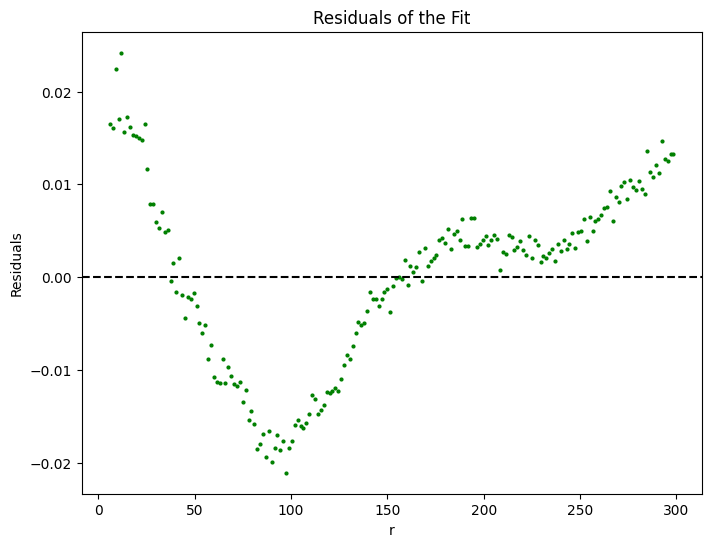

ref_1946
Fitted line: C = -0.100 * ln(r) + 0.674
Quality of the regression : 0.9466353138228938
C = -(0.100+/-0.003) * ln(r/(825.675+/-26.315))


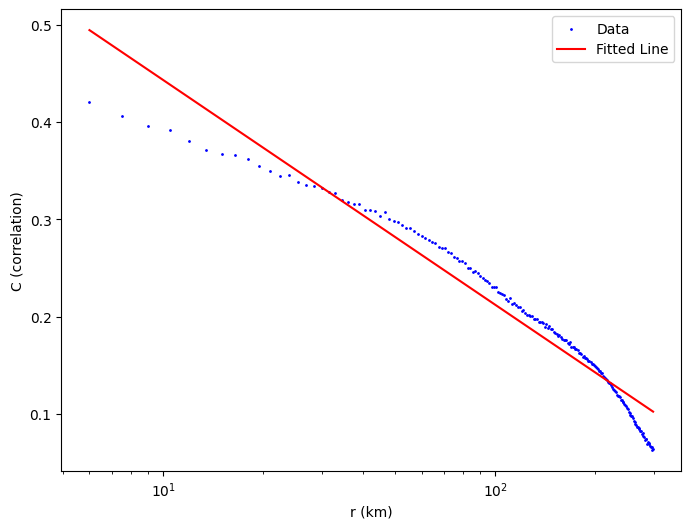

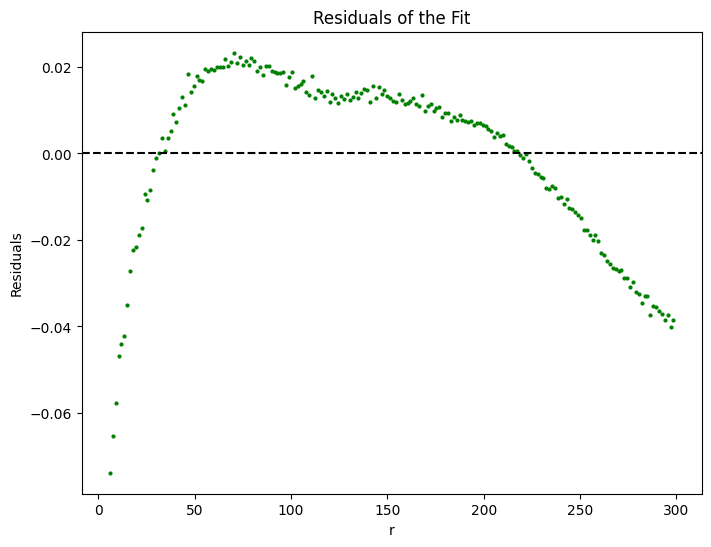

pres_2022
Fitted line: C = -0.058 * ln(r) + 0.338
Quality of the regression : 0.9718676441129014
C = -(0.058+/-0.001) * ln(r/(322.153+/-3.654))


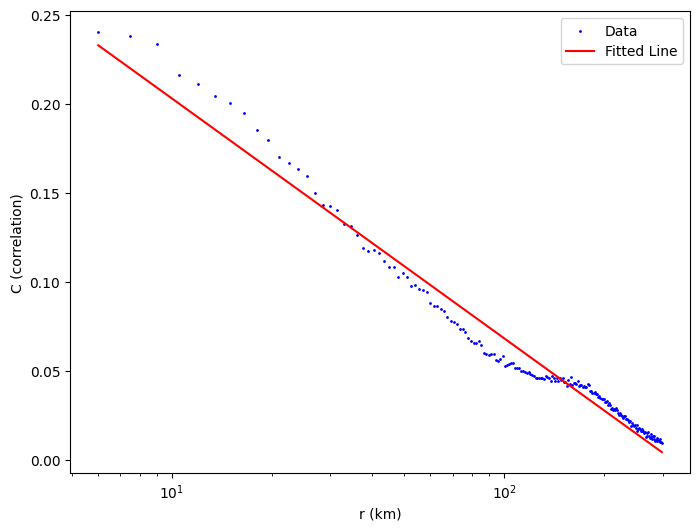

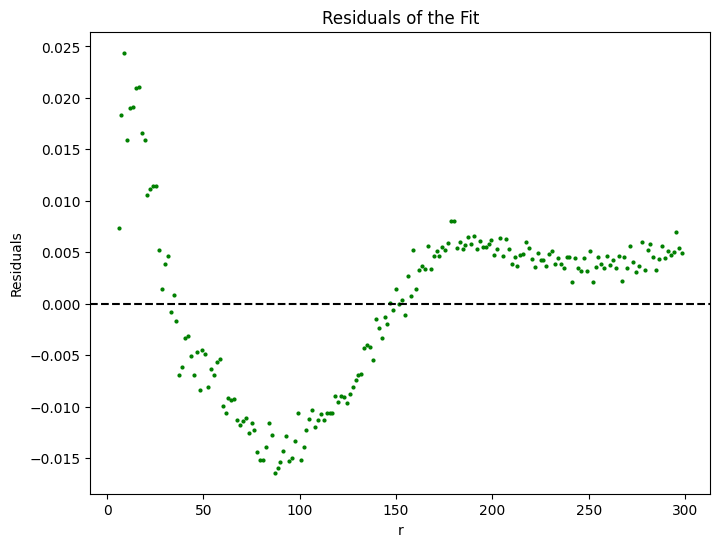

ref_1992
Fitted line: C = -0.082 * ln(r) + 0.479
Quality of the regression : 0.9882886734953141
C = -(0.082+/-0.001) * ln(r/(332.391+/-2.493))


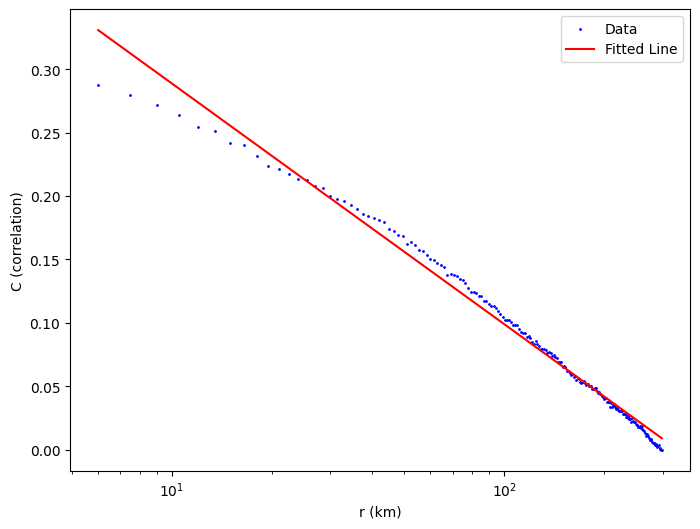

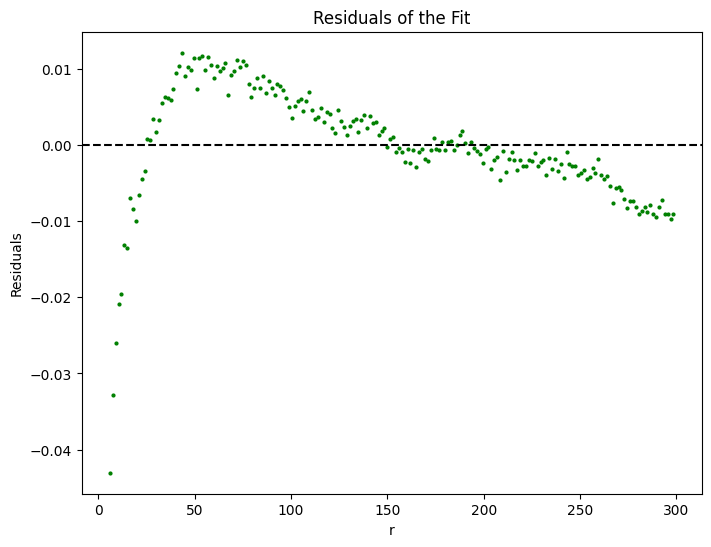

pres_1848
Fitted line: C = -0.150 * ln(r) + 0.898
Quality of the regression : 0.9839441509994068
C = -(0.150+/-0.002) * ln(r/(404.526+/-4.289))


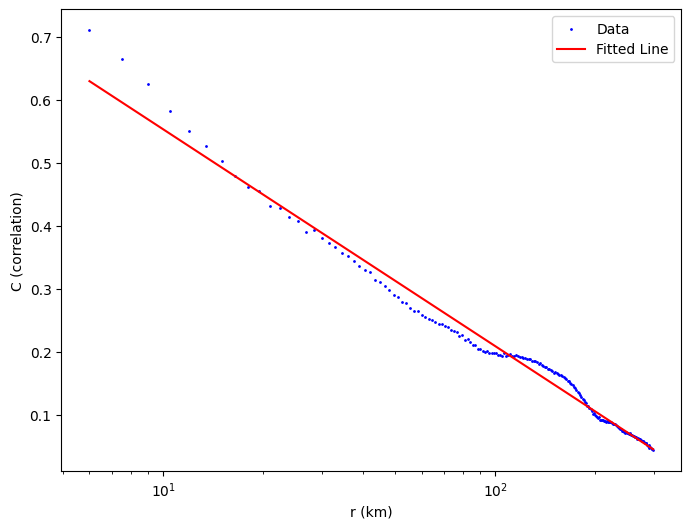

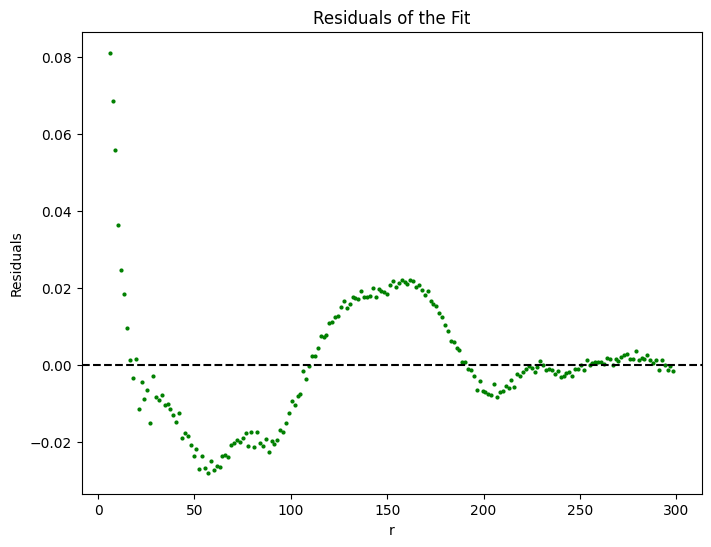

leg_1993
Fitted line: C = -0.085 * ln(r) + 0.477
Quality of the regression : 0.9933628210267432
C = -(0.085+/-0.001) * ln(r/(265.996+/-1.150))


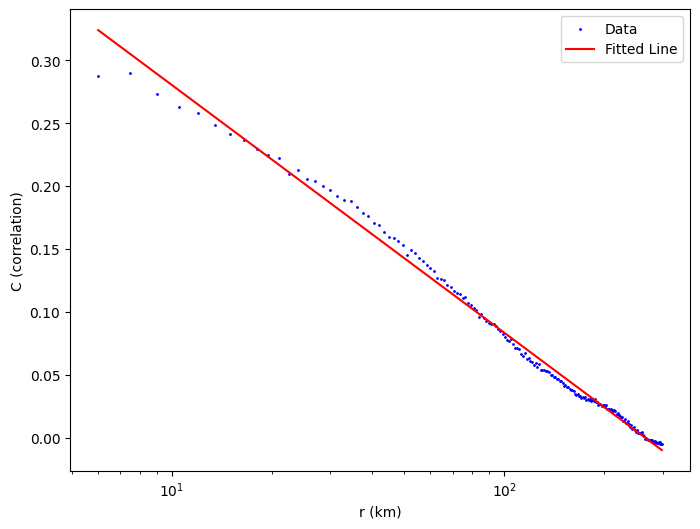

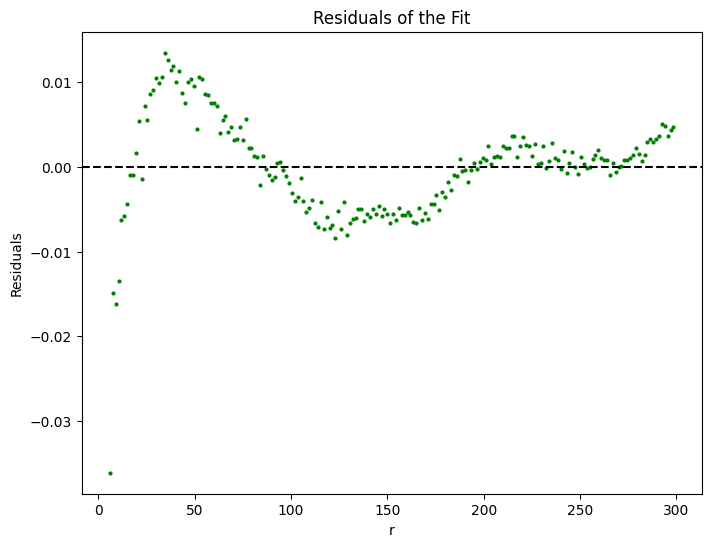

leg_1986
Fitted line: C = -0.095 * ln(r) + 0.523
Quality of the regression : 0.9729414299602576
C = -(0.095+/-0.002) * ln(r/(246.811+/-1.956))


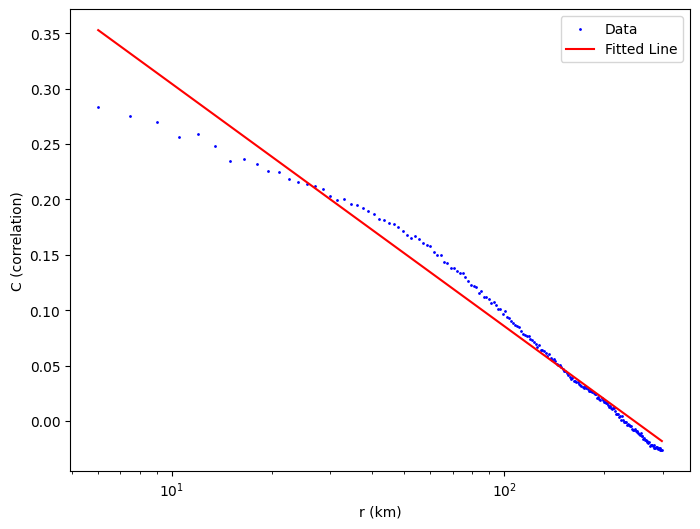

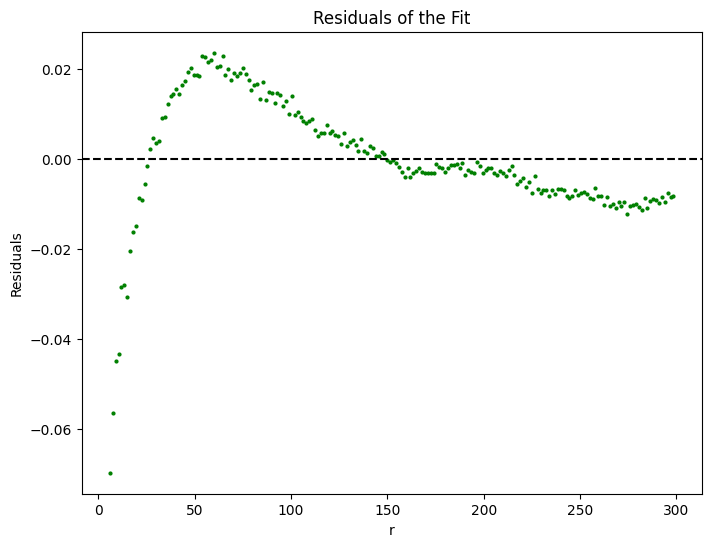

leg_1871
Fitted line: C = -0.115 * ln(r) + 0.600
Quality of the regression : 0.8727046983966973
C = -(0.115+/-0.005) * ln(r/(188.078+/-2.013))


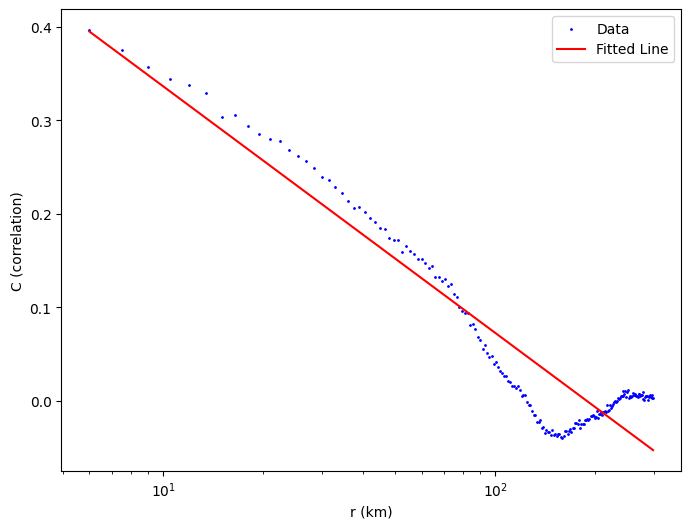

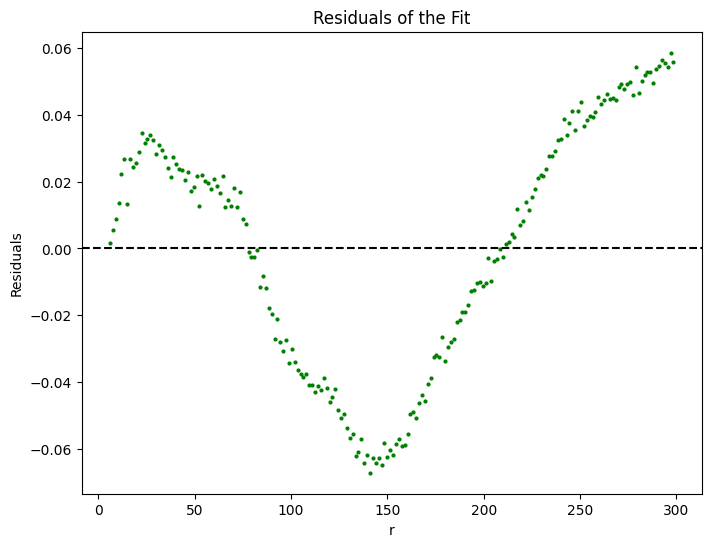

pres_2017
Fitted line: C = -0.054 * ln(r) + 0.292
Quality of the regression : 0.9545794367503485
C = -(0.054+/-0.002) * ln(r/(220.300+/-1.892))


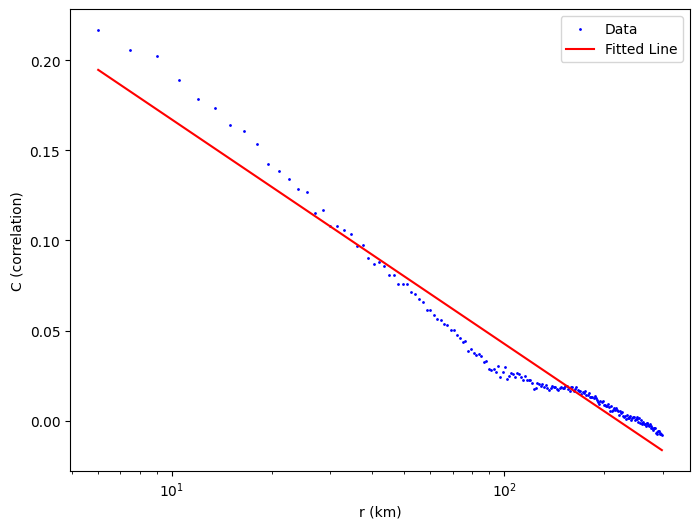

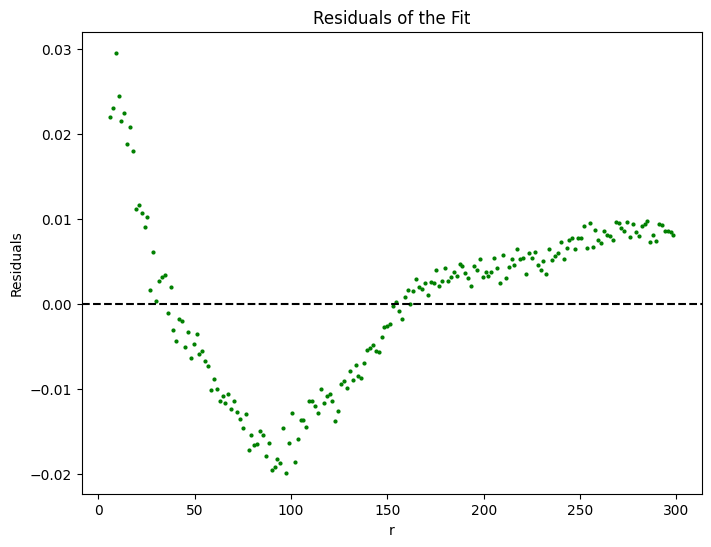

T2_pres_2017
Fitted line: C = -0.052 * ln(r) + 0.270
Quality of the regression : 0.923437658987584
C = -(0.052+/-0.002) * ln(r/(183.975+/-1.401))


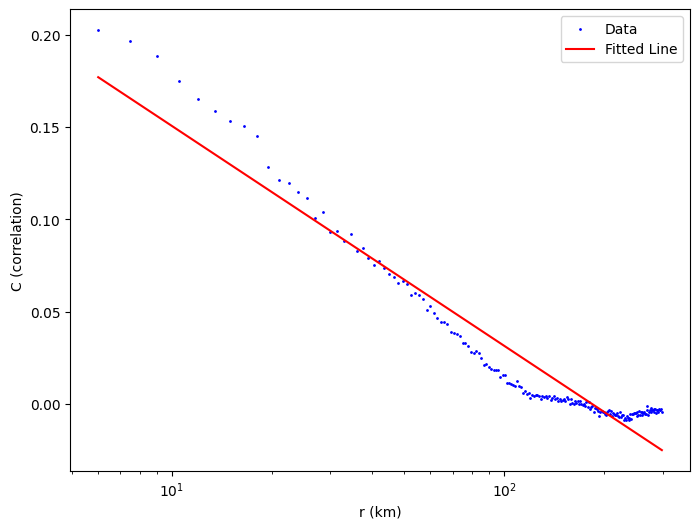

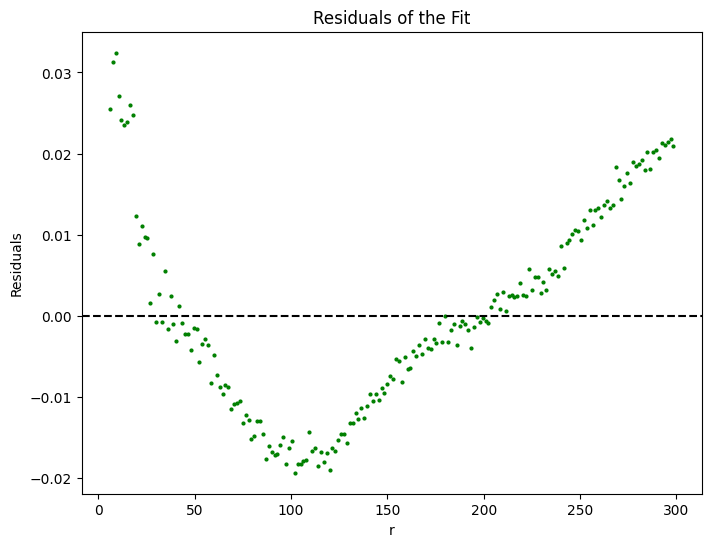

pres_2002
Fitted line: C = -0.075 * ln(r) + 0.387
Quality of the regression : 0.9355464251042185
C = -(0.075+/-0.003) * ln(r/(179.785+/-1.170))


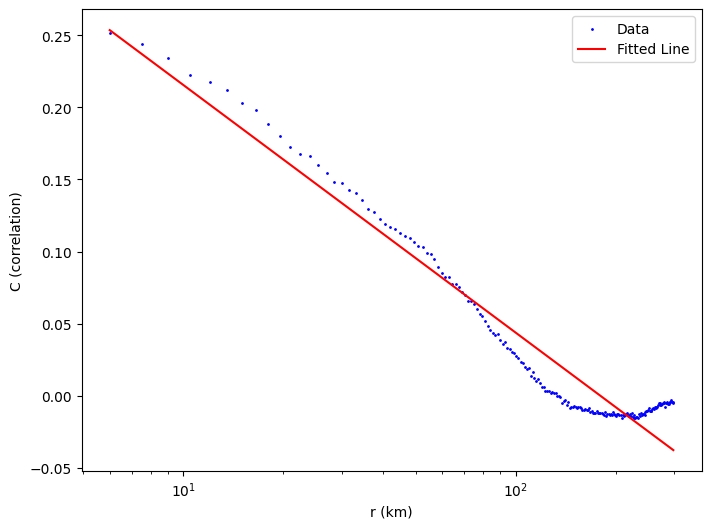

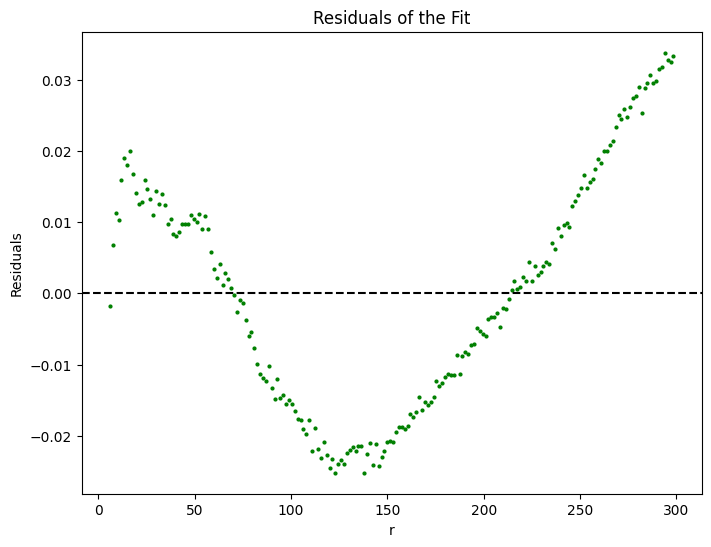

In [ ]:
LAMBD = {}
L_d = {}
R = {}
for key, df in dataframes.items():
    print(key)
    lambd, L, R_2 = fit_election(df, L_c, l_c, plot=True, resid=True)
    LAMBD[key] = lambd
    L_d[key] = L
    R[key] = R_2

In [ ]:
LAMBD

{'leg_1988': 0.31538872768026516,
 'ref_1795': 0.41385116458036786,
 'ref_1793': 0.43566502159675036,
 'T2_pres_2022': 0.2382970279810511,
 'leg_1973': 0.4704366392351438,
 'leg_1928': 0.28527658056364813,
 'pres_1969': 0.318697238195543,
 'T2_pres_1969': 0.31580464047313767,
 'pres_1981': 0.3180614951606103,
 'pres_1995': 0.27575758360752234,
 'T2_pres_1981': 0.2658688615662113,
 'leg_2012': 0.22454791193220935,
 'leg_1902': 0.3090460872262543,
 'leg_1898': 0.2992951143242553,
 'leg_1910': 0.3208777878008231,
 'pres_1974': 0.28045527285564176,
 'T2_pres_1974': 0.25772626931962384,
 'pres_1988': 0.3344472581685725,
 'T2_pres_1988': 0.27027402719702603,
 'leg_2022': 0.23010325021389738,
 'pres_1965': 0.3314448663254118,
 'leg_1919': 0.3356433845999175,
 'pres_2012': 0.21720380055252625,
 'T2_pres_2012': 0.20722930618858829,
 'pres_2007': 0.23226710242446286,
 'ref_1946': 0.3168932957941572,
 'pres_2022': 0.2417465208086845,
 'ref_1992': 0.2871210553892,
 'pres_1848': 0.38675017341327556

In [ ]:
# Combine dictionaries into a DataFrame
data = {
    "Key": list(R.keys()),
    "R": list(R.values()),
    "L_d": list(L_d.values()),
    "LAMBD^2": list(([lambd**2 for key, lambd in LAMBD.items()])),
}

df = pd.DataFrame(data)

# Sort the DataFrame by the 'Key' column (ascending order)
df_sorted = df.sort_values(by="Key").reset_index(drop=True)

# Display the table
print(df_sorted)

lambda_mean = np.mean(list(LAMBD.values()))
print("lambda_mean **2 : " + str(lambda_mean**2))

L_mean = np.mean(list(L_d.values()))
print("L_mean : " + str(L_mean))

R_2_mean = np.mean(list(R.values()))
print("R_2_mean : " + str(R_2_mean))

             Key         R          L_d   LAMBD^2
0   T2_pres_1969  0.987501   249.244370  0.099733
1   T2_pres_1974  0.976054   286.902813  0.066423
2   T2_pres_1981  0.982885   313.902931  0.070686
3   T2_pres_1988  0.976277   240.605674  0.073048
4   T2_pres_2012  0.974522   292.729120  0.042944
5   T2_pres_2017  0.923438   183.974996  0.051700
6   T2_pres_2022  0.888957   193.679622  0.056785
7       leg_1871  0.872705   188.077662  0.114628
8       leg_1898  0.901726   260.607618  0.089578
9       leg_1902  0.914945   228.923894  0.095509
10      leg_1910  0.929839   322.491846  0.102963
11      leg_1919  0.844147   187.242913  0.112656
12      leg_1928  0.992630   466.347329  0.081383
13      leg_1973  0.951610   465.164022  0.221311
14      leg_1986  0.972941   246.811012  0.094934
15      leg_1988  0.990118   254.746740  0.099470
16      leg_1993  0.993363   265.996277  0.085446
17      leg_2012  0.988931   262.567658  0.050422
18      leg_2022  0.981817  1055.799039  0.052948


Valeur dans l'article : The average logarithmic slope $\lambda^2$ is found to be  0.065±0.01 for turnout rates, and 0.11±0.02 for winning votes

On s'interesse à $\beta \sigma_{\phi}^2 = lim_{r\to0^+} C(r)$

In [ ]:
SIGMA_PHI = {}
for key in dataframes.keys():
    SIGMA_PHI[key] = dataframes[key].iloc[0]["correlation"]

In [ ]:
SIGMA_PHI

{'leg_1988': 0.364700271914542,
 'ref_1795': 0.8456387482424282,
 'ref_1793': 0.9224729544600799,
 'T2_pres_2022': 0.26672954015375205,
 'leg_1973': 0.8860280138719547,
 'leg_1928': 0.46676663327134965,
 'pres_1969': 0.4236080434653361,
 'T2_pres_1969': 0.45638078695748013,
 'pres_1981': 0.4098793197730662,
 'pres_1995': 0.2831032493999041,
 'T2_pres_1981': 0.2946380760957774,
 'leg_2012': 0.1494758873335705,
 'leg_1902': 0.5118685378588705,
 'leg_1898': 0.40858325061205547,
 'leg_1910': 0.5239479255133146,
 'pres_1974': 0.28475597774724615,
 'T2_pres_1974': 0.3378208006917974,
 'pres_1988': 0.45733527466736973,
 'T2_pres_1988': 0.2942295659700394,
 'leg_2022': 0.07853051229469357,
 'pres_1965': 0.41705301861082716,
 'leg_1919': 0.4444269647496801,
 'pres_2012': 0.1480678371018657,
 'T2_pres_2012': 0.1542543384822392,
 'pres_2007': 0.146415665194202,
 'ref_1946': 0.4567170823659816,
 'pres_2022': 0.21413831583789494,
 'ref_1992': 0.2820165066300463,
 'pres_1848': 0.8411670240504856,
 '